# Delhivery: ETA, Delay, and Delay Propagation Prediction — v6 — Full Multi-Model Delay Propagation Benchmark

This notebook keeps the previous version's leakage-prevention pipeline unchanged and expands model selection into a large benchmark comprising:

- the existing tree models: Decision Tree, Random Forest, Extra Trees, AdaBoost, XGBoost;
- Gradient Boosting, HistGradientBoosting, LightGBM, CatBoost, NGBoost, EBM, BART/GBART, and DART;
- SVM for regression/classification;
- the full set of linear/robust/GLM/online models as required;
- training every model whose dependencies are available, on the same full fit set;
- LIME/SHAP are temporarily commented out to avoid wasting time before the model is finalized.

The business objective is unchanged: predict full elapsed duration/ETA, delay magnitude, severe-delay probability, and delay propagation.

### v5.1 Update

- Keep the snapshot results of the 31 regressors and 18 classifiers already run in v5.
- Do not rerun the old model benchmark.
- Run only the new models belonging to Groups 4, 5, and 6.
- Merge the old and new leaderboards to select the best overall model.
- Refit only the overall winning model on the full `train_df` for the final test and artifact export.


### v6 Update

- Delay propagation is no longer fixed to a single `XGBRegressor`.
- Delay propagation now uses **the exact same 37-regressor registry as the ETA task**.
- The propagation model is selected using chronological stage-validation, not the final test set.
- Each model is evaluated at the 25%, 50%, 75%, and 100% checkpoints; the primary criterion is the mean MAE across the four checkpoints.
- The winning model is refit on the full stage-training set before being evaluated on the stage-test set.


## Table of Contents

1. [Environment Setup](#1-environment-setup)
2. [Data Loading](#2-data-loading)
3. [Data Quality Assessment](#3-data-quality-assessment)
4. [Preprocessing](#4-preprocessing)
5. [Aggregation: Segment → Leg → Trip](#5-aggregation-segment--leg--trip)
6. [EDA](#6-eda)
7. [Feature Engineering](#7-feature-engineering)
8. [Data Splitting and Leakage Prevention](#8-data-splitting-and-leakage-prevention)
9. [ETA Regression — Incremental Group 4–6](#9-eta-regression--incremental-group-46)
10. [Delay Magnitude Model](#10-delay-magnitude-model)
11. [Severe-Delay Classification — Incremental Group 4–6](#11-severe-delay-classification--incremental-group-46)
12. [Delay Propagation — Benchmark with the Same 37 ETA Regressors](#12-delay-propagation--benchmark-with-the-same-37-eta-regressors)
13. [Explainability with LIME/SHAP — Temporarily Commented Out](#13-explainability-with-limeshap--temporarily-commented-out)
14. [Single-Shipment Prediction Example](#14-single-shipment-prediction-example)
15. [Model Export and Conclusion](#15-model-export-and-conclusion)


## 1. Environment Setup


Core packages:

```bash
pip install pandas numpy scipy matplotlib seaborn scikit-learn xgboost joblib
```

Optional packages needed to run the full extended model set:

```bash
pip install imbalanced-learn

# Old model packages do not need to be reinstalled if only running the v5.1 incremental part. bartpy
```

- `lightgbm`, `catboost`, `ngboost`, `interpret`: additional boosting models.
- `ISLP` or `bartpy`: BART/GBART backend. The notebook prefers `ISLP.bart.BART`, falling back to BartPy.
- The next cell automatically checks for and installs any missing extended packages. On Kaggle, Internet access must be enabled if the environment lacks a package.
- LIME/SHAP are currently commented out, so they are not required during the benchmark stage.

The notebook runs a **full benchmark**: every model whose dependencies are available is trained on the complete chronological `fit` set, with no row limit and no mechanism to exclude heavy models from the best-model selection step.


In [6]:
AUTO_INSTALL_NEW_PACKAGES = True

if AUTO_INSTALL_NEW_PACKAGES:
    import importlib.util
    import subprocess
    import sys

    new_optional_packages = {
        'imblearn': 'imbalanced-learn',
    }

    for import_name, pip_name in new_optional_packages.items():
        if importlib.util.find_spec(import_name) is not None:
            print(f'Available: {import_name}')
            continue
        try:
            subprocess.check_call([
                sys.executable, '-m', 'pip', 'install', '-q', pip_name
            ])
            print(f'Installed: {pip_name}')
        except Exception as exc:
            print(f'Could not install {pip_name}: {type(exc).__name__}: {exc}')
else:
    print('AUTO_INSTALL_NEW_PACKAGES=False — chỉ dùng package có sẵn.')

Available: imblearn


In [7]:
from pathlib import Path
import os

os.environ.setdefault('OMP_NUM_THREADS', '1')
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')
os.environ.setdefault('MKL_NUM_THREADS', '1')
os.environ.setdefault('NUMEXPR_NUM_THREADS', '1')
from dataclasses import dataclass
from typing import Callable, Optional
import gc
import importlib.util
import inspect
import json
import time
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
from scipy.special import expit

from IPython.display import display

from sklearn.base import BaseEstimator, RegressorMixin, ClassifierMixin
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.decomposition import PCA
from sklearn.neighbors import (
    KNeighborsRegressor, KNeighborsClassifier,
    RadiusNeighborsRegressor, RadiusNeighborsClassifier,
)
from sklearn.naive_bayes import GaussianNB, BernoulliNB, MultinomialNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.gaussian_process import GaussianProcessRegressor, GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from sklearn.ensemble import (
    RandomForestRegressor,
    RandomForestClassifier,
    ExtraTreesRegressor,
    ExtraTreesClassifier,
    AdaBoostRegressor,
    AdaBoostClassifier,
    GradientBoostingRegressor,
    GradientBoostingClassifier,
    HistGradientBoostingRegressor,
    HistGradientBoostingClassifier,
    BaggingRegressor,
    BaggingClassifier,
)
from sklearn.svm import SVR, SVC, LinearSVR, LinearSVC, NuSVR, NuSVC
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet,
    BayesianRidge,
    ARDRegression,
    HuberRegressor,
    TheilSenRegressor,
    RANSACRegressor,
    QuantileRegressor,
    PoissonRegressor,
    GammaRegressor,
    TweedieRegressor,
    SGDRegressor,
    PassiveAggressiveRegressor,
    LogisticRegression,
    SGDClassifier,
    PassiveAggressiveClassifier,
)
from sklearn.metrics import (
    mean_absolute_error,
    median_absolute_error,
    root_mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBRegressor, XGBClassifier

OPTIONAL_DEPENDENCIES = {}

try:
    from lightgbm import LGBMRegressor, LGBMClassifier
    OPTIONAL_DEPENDENCIES['lightgbm'] = (True, '')
except Exception as exc:
    LGBMRegressor = LGBMClassifier = None
    OPTIONAL_DEPENDENCIES['lightgbm'] = (False, f'{type(exc).__name__}: {exc}')

try:
    from catboost import CatBoostRegressor, CatBoostClassifier
    OPTIONAL_DEPENDENCIES['catboost'] = (True, '')
except Exception as exc:
    CatBoostRegressor = CatBoostClassifier = None
    OPTIONAL_DEPENDENCIES['catboost'] = (False, f'{type(exc).__name__}: {exc}')

try:
    from ngboost import NGBRegressor, NGBClassifier
    OPTIONAL_DEPENDENCIES['ngboost'] = (True, '')
except Exception as exc:
    NGBRegressor = NGBClassifier = None
    OPTIONAL_DEPENDENCIES['ngboost'] = (False, f'{type(exc).__name__}: {exc}')

try:
    from interpret.glassbox import ExplainableBoostingRegressor, ExplainableBoostingClassifier
    OPTIONAL_DEPENDENCIES['interpret'] = (True, '')
except Exception as exc:
    ExplainableBoostingRegressor = ExplainableBoostingClassifier = None
    OPTIONAL_DEPENDENCIES['interpret'] = (False, f'{type(exc).__name__}: {exc}')

try:
    from imblearn.ensemble import (
        BalancedRandomForestClassifier,
        EasyEnsembleClassifier,
        RUSBoostClassifier,
    )
    OPTIONAL_DEPENDENCIES['imbalanced_learn'] = (True, '')
except Exception as exc:
    BalancedRandomForestClassifier = EasyEnsembleClassifier = RUSBoostClassifier = None
    OPTIONAL_DEPENDENCIES['imbalanced_learn'] = (False, f'{type(exc).__name__}: {exc}')

BART_BACKEND = None
BART_CLASS = None
try:
    from ISLP.bart import BART as ISLP_BART
    BART_BACKEND = 'ISLP'
    BART_CLASS = ISLP_BART
    OPTIONAL_DEPENDENCIES['bart'] = (True, 'ISLP.bart.BART')
except Exception as islp_exc:
    try:
        from bartpy.sklearnmodel import SklearnModel as BartPyModel
        BART_BACKEND = 'bartpy'
        BART_CLASS = BartPyModel
        OPTIONAL_DEPENDENCIES['bart'] = (True, 'bartpy.sklearnmodel.SklearnModel')
    except Exception as bartpy_exc:
        OPTIONAL_DEPENDENCIES['bart'] = (
            False,
            f'ISLP: {type(islp_exc).__name__}: {islp_exc}; '
            f'bartpy: {type(bartpy_exc).__name__}: {bartpy_exc}'
        )


warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 120)
pd.set_option('display.max_colwidth', 180)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
DELAY_THRESHOLD_MINUTES = 120
N_JOBS = 2


optional_status_df = pd.DataFrame([
    {
        'Dependency': name,
        'Available': status[0],
        'Backend / error': status[1],
    }
    for name, status in OPTIONAL_DEPENDENCIES.items()
])
display(optional_status_df.style.set_caption('Optional dependency status'))

,Dependency,Available,Backend / error
0,lightgbm,True,
1,catboost,True,
2,ngboost,False,ModuleNotFoundError: No module named 'ngboost'
3,interpret,False,ModuleNotFoundError: No module named 'interpret'
4,imbalanced_learn,True,
5,bart,False,ISLP: ModuleNotFoundError: No module named 'ISLP'; bartpy: ModuleNotFoundError: No module named 'bartpy'


## 2. Data Loading


On Kaggle, the dataset is loaded directly from the `/kaggle/input` path. The cell below prioritizes the user-supplied path and falls back to local paths when running locally.


In [8]:
KAGGLE_DATA_PATH = Path(
    '/kaggle/input/datasets/santanukundu/delhivery-dataset/delhivery_data.csv'
)


def find_data_path(filename='delhivery_data.csv'):
    candidates = [
        KAGGLE_DATA_PATH,
        Path('/kaggle/input/delhivery-dataset') / filename,
        Path(filename),
        Path('data') / filename,
        Path('Delhivery-Logistics-Shipment-Data-Analysis-main') / filename,
        Path('repo2') / 'Delhivery-Logistics-Shipment-Data-Analysis-main' / filename,
    ]

    for path in candidates:
        if path.exists():
            return path.resolve()

    matches = list(Path.cwd().glob(f'**/{filename}'))
    if matches:
        return matches[0].resolve()

    checked = '\n'.join(f'- {path}' for path in candidates)
    raise FileNotFoundError(
        f'Không tìm thấy {filename}. Các đường dẫn đã kiểm tra:\n{checked}'
    )


DATA_PATH = find_data_path()
print(f'Data path: {DATA_PATH}')

raw_df = pd.read_csv(DATA_PATH)
print(f'Raw shape: {raw_df.shape[0]:,} rows × {raw_df.shape[1]} columns')
display(raw_df.head())


Data path: /kaggle/input/datasets/santanukundu/delhivery-dataset/delhivery_data.csv
Raw shape: 144,867 rows × 24 columns


,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,od_end_time,start_scan_to_end_scan,is_cutoff,cutoff_factor,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3297ef,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.000,True,9,2018-09-20 04:27:55,10.436,14.000,11.000,11.965,1.273,14.000,11.000,11.965,1.273
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3297ef,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.000,True,18,2018-09-20 04:17:55,18.937,24.000,20.000,21.724,1.200,10.000,9.000,9.759,1.111
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3297ef,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.000,True,27,2018-09-20 04:01:19.505586,27.637,40.000,28.000,32.539,1.429,16.000,7.000,10.815,2.286
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3297ef,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.000,True,36,2018-09-20 03:39:57,36.118,62.000,40.000,45.562,1.550,21.000,12.000,13.022,1.750
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3297ef,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.000,False,39,2018-09-20 03:33:55,39.386,68.000,44.000,54.218,1.545,6.000,5.000,3.915,1.200


### Condensed Data Dictionary

| Category | Main Fields | Purpose |
|---|---|---|
| ID | `trip_uuid`, `route_schedule_uuid` | Identify the trip and route schedule |
| Route | `source_*`, `destination_*`, `route_type` | Geographic and transport-type features |
| Ground truth | `od_start_time`, `od_end_time` | Compute the actual duration and final ETA |
| Plan | `osrm_time`, `osrm_distance`, `segment_osrm_*` | Routing baseline used to compute the proxy delay |
| Dynamic actuals | `segment_actual_time`, `cutoff_timestamp` | Only usable after the checkpoint has occurred |
| Audit | `actual_time`, `factor`, `segment_factor` | Not used as a start-of-trip target/feature because of leakage risk or because it does not represent the full elapsed time |


## 3. Data Quality Assessment


In [9]:
quality_summary = pd.DataFrame({
    'dtype': raw_df.dtypes.astype(str),
    'missing_count': raw_df.isna().sum(),
    'missing_pct': raw_df.isna().mean().mul(100),
    'n_unique': raw_df.nunique(dropna=False),
}).sort_values('missing_pct', ascending=False)

display(quality_summary)

print(f'Exact duplicate rows: {raw_df.duplicated().sum():,}')
print(f'Unique trips: {raw_df["trip_uuid"].nunique():,}')
print(f'Negative segment_actual_time rows: {(raw_df["segment_actual_time"] < 0).sum():,}')
print(f'Non-positive segment_osrm_time rows: {(raw_df["segment_osrm_time"] <= 0).sum():,}')

,dtype,missing_count,missing_pct,n_unique
source_name,object,293,0.202,1499
destination_name,object,261,0.180,1469
route_schedule_uuid,object,0,0.000,1504
data,object,0,0.000,2
route_type,object,0,0.000,2
trip_uuid,object,0,0.000,14817
source_center,object,0,0.000,1508
trip_creation_time,object,0,0.000,14817
destination_center,object,0,0.000,1481
od_start_time,object,0,0.000,26369


Exact duplicate rows: 0
Unique trips: 14,817
Negative segment_actual_time rows: 21
Non-positive segment_osrm_time rows: 2,347


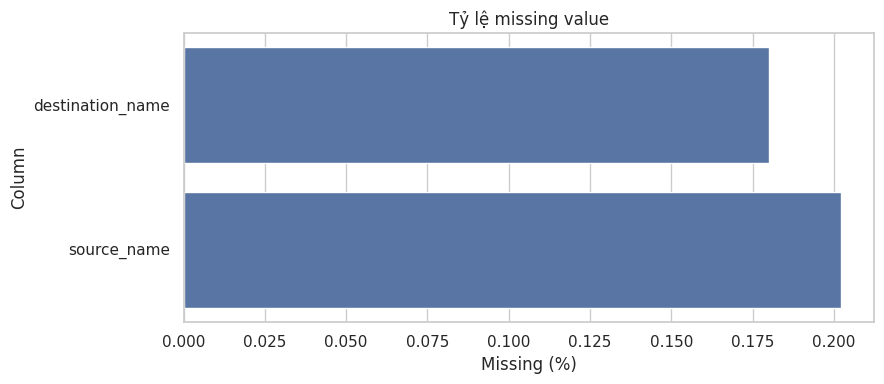

In [10]:
missing = quality_summary.query('missing_count > 0').sort_values('missing_pct')
if not missing.empty:
    plt.figure(figsize=(9, 4))
    sns.barplot(data=missing.reset_index(), x='missing_pct', y='index', color='C0')
    plt.xlabel('Missing (%)')
    plt.ylabel('Column')
    plt.title('Tỷ lệ missing value')
    plt.tight_layout()
    plt.show()
else:
    print('Không có missing value.')

## 4. Preprocessing


Processing principles:

- Do not modify the original dataframe directly; work on a copy.
- Convert columns to the correct datetime type.
- Fill missing location names with the most common/first name within the same `center`, then fall back to the center code.
- Split `city` and `state` out of the location name.
- Keep anomaly flags instead of removing all logistics outliers, since long trips or large delays may be genuine data.


In [11]:
df = raw_df.copy()
df = df.drop_duplicates().reset_index(drop=True)

DATETIME_COLUMNS = [
    'trip_creation_time', 'od_start_time', 'od_end_time', 'cutoff_timestamp'
]


def parse_mixed_datetime(series):
    """Parse timestamp có/không có microseconds mà không làm mất dữ liệu hợp lệ."""
    try:
        return pd.to_datetime(series, format='mixed', errors='coerce')
    except TypeError:
        return pd.to_datetime(series, errors='coerce')


for col in DATETIME_COLUMNS:
    df[col] = parse_mixed_datetime(df[col])

df['source_name'] = (
    df['source_name']
      .fillna(df.groupby('source_center')['source_name'].transform('first'))
      .fillna(df['source_center'])
)
df['destination_name'] = (
    df['destination_name']
      .fillna(df.groupby('destination_center')['destination_name'].transform('first'))
      .fillna(df['destination_center'])
)


def extract_city(series):
    return series.astype(str).str.split('_').str[0].str.strip()


def extract_state(series):
    return (
        series.astype(str)
              .str.extract(r'\(([^()]*)\)\s*$', expand=False)
              .fillna('Unknown')
              .str.strip()
    )


df['source_city'] = extract_city(df['source_name'])
df['destination_city'] = extract_city(df['destination_name'])
df['source_state'] = extract_state(df['source_name'])
df['destination_state'] = extract_state(df['destination_name'])

df['negative_segment_time_flag'] = (df['segment_actual_time'] < 0).astype(int)
df['zero_segment_plan_flag'] = (df['segment_osrm_time'] <= 0).astype(int)
df['_row_order'] = np.arange(len(df))

print('Remaining missing values:')
display(df.isna().sum()[df.isna().sum() > 0])
print(f"Missing cutoff_timestamp after mixed parsing: {df['cutoff_timestamp'].isna().sum():,}")
display(df.head())

Remaining missing values:


Series([], dtype: int64)

Missing cutoff_timestamp after mixed parsing: 0


,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,od_end_time,start_scan_to_end_scan,is_cutoff,cutoff_factor,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor,source_city,destination_city,source_state,destination_state,negative_segment_time_flag,zero_segment_plan_flag,_row_order
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3297ef,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.000,True,9,2018-09-20 04:27:55.000000,10.436,14.000,11.000,11.965,1.273,14.000,11.000,11.965,1.273,Anand,Khambhat,Gujarat,Gujarat,0,0,0
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3297ef,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.000,True,18,2018-09-20 04:17:55.000000,18.937,24.000,20.000,21.724,1.200,10.000,9.000,9.759,1.111,Anand,Khambhat,Gujarat,Gujarat,0,0,1
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3297ef,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.000,True,27,2018-09-20 04:01:19.505586,27.637,40.000,28.000,32.539,1.429,16.000,7.000,10.815,2.286,Anand,Khambhat,Gujarat,Gujarat,0,0,2
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3297ef,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.000,True,36,2018-09-20 03:39:57.000000,36.118,62.000,40.000,45.562,1.550,21.000,12.000,13.022,1.750,Anand,Khambhat,Gujarat,Gujarat,0,0,3
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3297ef,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.000,False,39,2018-09-20 03:33:55.000000,39.386,68.000,44.000,54.218,1.545,6.000,5.000,3.915,1.200,Anand,Khambhat,Gujarat,Gujarat,0,0,4


## 5. Aggregation: Segment → Leg → Trip


The raw dataset has multiple checkpoints for the same leg and multiple legs for the same trip. Training directly on individual rows could let checkpoints from the same trip fall into both train and test, artificially inflating the metric.

Aggregation pipeline:

1. **Checkpoint row**: a dynamic observation recorded during the journey.
2. **Leg**: rows sharing `trip_uuid + source + destination + od_start_time`.
3. **Trip**: a single row for each `trip_uuid`.

Checkpoints are sorted by `cutoff_timestamp`. Cumulative fields at the leg level use `max`; incremental fields use `sum`. The final ground truth is not taken from `actual_time`, but is computed from the trip's start/end timestamps.


In [12]:
df_sorted = df.sort_values(
    ['trip_uuid', 'od_start_time', 'cutoff_timestamp', '_row_order'],
    na_position='last',
).copy()

leg_keys = ['trip_uuid', 'source_center', 'destination_center', 'od_start_time']

leg_df = df_sorted.groupby(leg_keys, as_index=False).agg(
    data=('data', 'first'),
    route_schedule_uuid=('route_schedule_uuid', 'first'),
    route_type=('route_type', 'first'),
    trip_creation_time=('trip_creation_time', 'first'),
    source_name=('source_name', 'first'),
    destination_name=('destination_name', 'last'),
    source_city=('source_city', 'first'),
    destination_city=('destination_city', 'last'),
    source_state=('source_state', 'first'),
    destination_state=('destination_state', 'last'),
    od_end_time=('od_end_time', 'max'),
    start_scan_to_end_scan=('start_scan_to_end_scan', 'max'),
    actual_distance_to_destination=('actual_distance_to_destination', 'max'),
    actual_time=('actual_time', 'max'),
    osrm_time=('osrm_time', 'max'),
    osrm_distance=('osrm_distance', 'max'),
    segment_actual_time=('segment_actual_time', 'sum'),
    segment_osrm_time=('segment_osrm_time', 'sum'),
    segment_osrm_distance=('segment_osrm_distance', 'sum'),
    checkpoint_count=('trip_uuid', 'size'),
    cutoff_rate=('is_cutoff', 'mean'),
    anomaly_count=('negative_segment_time_flag', 'sum'),
    zero_plan_count=('zero_segment_plan_flag', 'sum'),
)

leg_df = leg_df.sort_values(['trip_uuid', 'od_start_time']).reset_index(drop=True)
print(f'Leg-level shape: {leg_df.shape}')
display(leg_df.head())

Leg-level shape: (26369, 27)


,trip_uuid,source_center,destination_center,od_start_time,data,route_schedule_uuid,route_type,trip_creation_time,source_name,destination_name,source_city,destination_city,source_state,destination_state,od_end_time,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance,checkpoint_count,cutoff_rate,anomaly_count,zero_plan_count
0,trip-153671041653548748,IND462022AAA,IND209304AAA,2018-09-12 00:00:16.535741,training,thanos::sroute:d7c989ba-a29b-4a0b-b2f4-288cdc60074b,FTL,2018-09-12 00:00:16.535741,Bhopal_Trnsport_H (Madhya Pradesh),Kanpur_Central_H_6 (Uttar Pradesh),Bhopal,Kanpur,Madhya Pradesh,Uttar Pradesh,2018-09-12 16:39:46.858469,999.000,440.974,830.000,394.000,544.803,820.000,474.000,649.853,21,0.952,0,0
1,trip-153671041653548748,IND209304AAA,IND000000ACB,2018-09-12 16:39:46.858469,training,thanos::sroute:d7c989ba-a29b-4a0b-b2f4-288cdc60074b,FTL,2018-09-12 00:00:16.535741,Kanpur_Central_H_6 (Uttar Pradesh),Gurgaon_Bilaspur_HB (Haryana),Kanpur,Gurgaon,Uttar Pradesh,Haryana,2018-09-13 13:40:23.123744,"1,260.000",383.759,732.000,349.000,446.550,728.000,534.000,670.620,18,0.944,0,0
2,trip-153671042288605164,IND572101AAA,IND561203AAB,2018-09-12 00:00:22.886430,training,thanos::sroute:3a1b0ab2-bb0b-4c53-8c59-eb2a2c0d68b9,Carting,2018-09-12 00:00:22.886430,Tumkur_Veersagr_I (Karnataka),Doddablpur_ChikaDPP_D (Karnataka),Tumkur,Doddablpur,Karnataka,Karnataka,2018-09-12 02:03:09.655591,122.000,48.543,96.000,42.000,56.912,95.000,39.000,55.990,6,0.833,0,0
3,trip-153671042288605164,IND561203AAB,IND562101AAA,2018-09-12 02:03:09.655591,training,thanos::sroute:3a1b0ab2-bb0b-4c53-8c59-eb2a2c0d68b9,Carting,2018-09-12 00:00:22.886430,Doddablpur_ChikaDPP_D (Karnataka),Chikblapur_ShntiSgr_D (Karnataka),Doddablpur,Chikblapur,Karnataka,Karnataka,2018-09-12 03:01:59.598855,58.000,24.644,47.000,26.000,28.199,46.000,26.000,28.200,3,0.667,0,0
4,trip-153671043369099517,IND562132AAA,IND000000ACB,2018-09-12 00:00:33.691250,training,thanos::sroute:de5e208e-7641-45e6-8100-4d9fb1e5720d,FTL,2018-09-12 00:00:33.691250,Bangalore_Nelmngla_H (Karnataka),Gurgaon_Bilaspur_HB (Haryana),Bangalore,Gurgaon,Karnataka,Haryana,2018-09-14 03:40:17.106733,"3,099.000","1,689.965","2,736.000","1,529.000","2,090.874","2,700.000","1,710.000","2,227.527",77,0.987,0,0


In [13]:
trip_df = leg_df.groupby('trip_uuid', as_index=False).agg(
    data=('data', 'first'),
    route_schedule_uuid=('route_schedule_uuid', 'first'),
    route_type=('route_type', 'first'),
    trip_creation_time=('trip_creation_time', 'first'),
    source_center=('source_center', 'first'),
    destination_center=('destination_center', 'last'),
    source_name=('source_name', 'first'),
    destination_name=('destination_name', 'last'),
    source_city=('source_city', 'first'),
    destination_city=('destination_city', 'last'),
    source_state=('source_state', 'first'),
    destination_state=('destination_state', 'last'),
    trip_start_time=('od_start_time', 'min'),
    trip_end_time=('od_end_time', 'max'),
    leg_count=('trip_uuid', 'size'),
    checkpoint_count=('checkpoint_count', 'sum'),
    start_scan_to_end_scan=('start_scan_to_end_scan', 'sum'),
    actual_distance_to_destination=('actual_distance_to_destination', 'sum'),
    actual_time=('actual_time', 'sum'),
    osrm_time=('osrm_time', 'sum'),
    osrm_distance=('osrm_distance', 'sum'),
    segment_actual_time=('segment_actual_time', 'sum'),
    segment_osrm_time=('segment_osrm_time', 'sum'),
    segment_osrm_distance=('segment_osrm_distance', 'sum'),
    cutoff_rate=('cutoff_rate', 'mean'),
    anomaly_count=('anomaly_count', 'sum'),
    zero_plan_count=('zero_plan_count', 'sum'),
)

trip_df['trip_duration_minutes'] = (
    trip_df['trip_end_time'] - trip_df['trip_start_time']
).dt.total_seconds() / 60

trip_df = trip_df.query(
    'trip_duration_minutes > 0 and osrm_time > 0 and osrm_distance > 0'
).copy()
trip_df = trip_df.sort_values('trip_creation_time').reset_index(drop=True)

print(f'Trip-level shape: {trip_df.shape}')
print(f'Unique trip_uuid after aggregation: {trip_df.trip_uuid.nunique():,}')
display(trip_df.head())

Trip-level shape: (14817, 29)
Unique trip_uuid after aggregation: 14,817


,trip_uuid,data,route_schedule_uuid,route_type,trip_creation_time,source_center,destination_center,source_name,destination_name,source_city,destination_city,source_state,destination_state,trip_start_time,trip_end_time,leg_count,checkpoint_count,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance,cutoff_rate,anomaly_count,zero_plan_count,trip_duration_minutes
0,trip-153671041653548748,training,thanos::sroute:d7c989ba-a29b-4a0b-b2f4-288cdc60074b,FTL,2018-09-12 00:00:16.535741,IND462022AAA,IND000000ACB,Bhopal_Trnsport_H (Madhya Pradesh),Gurgaon_Bilaspur_HB (Haryana),Bhopal,Gurgaon,Madhya Pradesh,Haryana,2018-09-12 00:00:16.535741,2018-09-13 13:40:23.123744,2,39,"2,259.000",824.733,"1,562.000",743.000,991.352,"1,548.000","1,008.000","1,320.473",0.948,0,0,"2,260.110"
1,trip-153671042288605164,training,thanos::sroute:3a1b0ab2-bb0b-4c53-8c59-eb2a2c0d68b9,Carting,2018-09-12 00:00:22.886430,IND572101AAA,IND562101AAA,Tumkur_Veersagr_I (Karnataka),Chikblapur_ShntiSgr_D (Karnataka),Tumkur,Chikblapur,Karnataka,Karnataka,2018-09-12 00:00:22.886430,2018-09-12 03:01:59.598855,2,9,180.000,73.187,143.000,68.000,85.111,141.000,65.000,84.189,0.750,0,0,181.612
2,trip-153671043369099517,training,thanos::sroute:de5e208e-7641-45e6-8100-4d9fb1e5720d,FTL,2018-09-12 00:00:33.691250,IND562132AAA,IND160002AAC,Bangalore_Nelmngla_H (Karnataka),Chandigarh_Mehmdpur_H (Punjab),Bangalore,Chandigarh,Karnataka,Punjab,2018-09-12 00:00:33.691250,2018-09-14 17:34:55.442454,2,89,"3,933.000","1,932.274","3,347.000","1,741.000","2,372.085","3,308.000","1,941.000","2,545.268",0.952,0,0,"3,934.363"
3,trip-153671046011330457,training,thanos::sroute:f0176492-a679-4597-8332-bbd1c7f9f442,Carting,2018-09-12 00:01:00.113710,IND400072AAB,IND401104AAA,Mumbai Hub (Maharashtra),Mumbai_MiraRd_IP (Maharashtra),Mumbai Hub (Maharashtra),Mumbai,Maharashtra,Maharashtra,2018-09-12 00:01:00.113710,2018-09-12 01:41:29.809822,1,2,100.000,17.175,59.000,15.000,19.680,59.000,16.000,19.877,0.500,0,0,100.495
4,trip-153671052974046625,training,thanos::sroute:d9f07b12-65e0-4f3b-bec8-df0613461b0f,FTL,2018-09-12 00:02:09.740725,IND583101AAA,IND583101AAA,Bellary_Dc (Karnataka),Bellary_Dc (Karnataka),Bellary,Bellary,Karnataka,Karnataka,2018-09-12 00:02:09.740725,2018-09-12 12:00:30.683231,3,7,717.000,127.448,341.000,117.000,146.792,340.000,115.000,146.792,0.556,0,0,718.349


In [14]:
trip_df['actual_time_gap_vs_elapsed'] = (
    trip_df['trip_duration_minutes'] - trip_df['actual_time']
)

consistency = pd.DataFrame({
    'metric': [
        'trip_duration vs actual_time (audit only)',
        'actual_time vs segment_actual_time',
        'osrm_time vs segment_osrm_time',
        'osrm_distance vs segment_osrm_distance',
    ],
    'correlation': [
        trip_df['trip_duration_minutes'].corr(trip_df['actual_time']),
        trip_df['actual_time'].corr(trip_df['segment_actual_time']),
        trip_df['osrm_time'].corr(trip_df['segment_osrm_time']),
        trip_df['osrm_distance'].corr(trip_df['segment_osrm_distance']),
    ]
})
display(consistency)

display(
    trip_df['actual_time_gap_vs_elapsed']
           .describe(percentiles=[.25, .5, .75, .9, .95, .99])
           .to_frame('elapsed_minus_actual_time_minutes')
)

,metric,correlation
0,trip_duration vs actual_time (audit only),0.953
1,actual_time vs segment_actual_time,1.000
2,osrm_time vs segment_osrm_time,0.994
3,osrm_distance vs segment_osrm_distance,0.995


,elapsed_minus_actual_time_minutes
count,"14,817.000"
mean,190.323
std,217.054
min,0.184
25%,55.540
50%,117.042
75%,237.548
90%,460.006
95%,631.868
99%,965.492


## 6. EDA


In [15]:
trip_df['actual_eta'] = trip_df['trip_end_time']
trip_df['osrm_eta'] = trip_df['trip_start_time'] + pd.to_timedelta(trip_df['osrm_time'], unit='m')
trip_df['delay_minutes'] = trip_df['trip_duration_minutes'] - trip_df['osrm_time']
trip_df['delay_ratio'] = trip_df['trip_duration_minutes'] / trip_df['osrm_time']

summary_cols = [
    'trip_duration_minutes', 'actual_time', 'osrm_time', 'delay_minutes',
    'osrm_distance', 'leg_count', 'checkpoint_count'
]
display(trip_df[summary_cols].describe(percentiles=[.1, .25, .5, .75, .9, .95, .99]).T)

,count,mean,std,min,10%,25%,50%,75%,90%,95%,99%,max
trip_duration_minutes,"14,817.000",547.477,668.687,23.461,93.741,151.158,288.570,673.301,"1,317.830","1,939.872","3,338.654","7,898.552"
actual_time,"14,817.000",357.154,561.406,9.000,42.000,67.000,149.000,370.000,893.000,"1,471.400","2,952.840","6,265.000"
osrm_time,"14,817.000",162.073,272.305,6.000,18.000,29.000,60.000,169.000,389.000,709.200,"1,535.000","2,032.000"
delay_minutes,"14,817.000",385.404,433.278,-8.034,65.440,111.315,215.123,490.991,972.106,"1,282.362","2,030.103","7,687.552"
osrm_distance,"14,817.000",205.104,370.780,9.073,19.338,30.942,65.883,209.300,490.841,969.316,"2,065.163","2,840.081"
leg_count,"14,817.000",1.780,1.203,1.000,1.000,1.000,1.000,2.000,4.000,4.000,6.000,8.000
checkpoint_count,"14,817.000",9.777,13.596,1.000,2.000,3.000,5.000,10.000,21.000,38.000,77.000,101.000


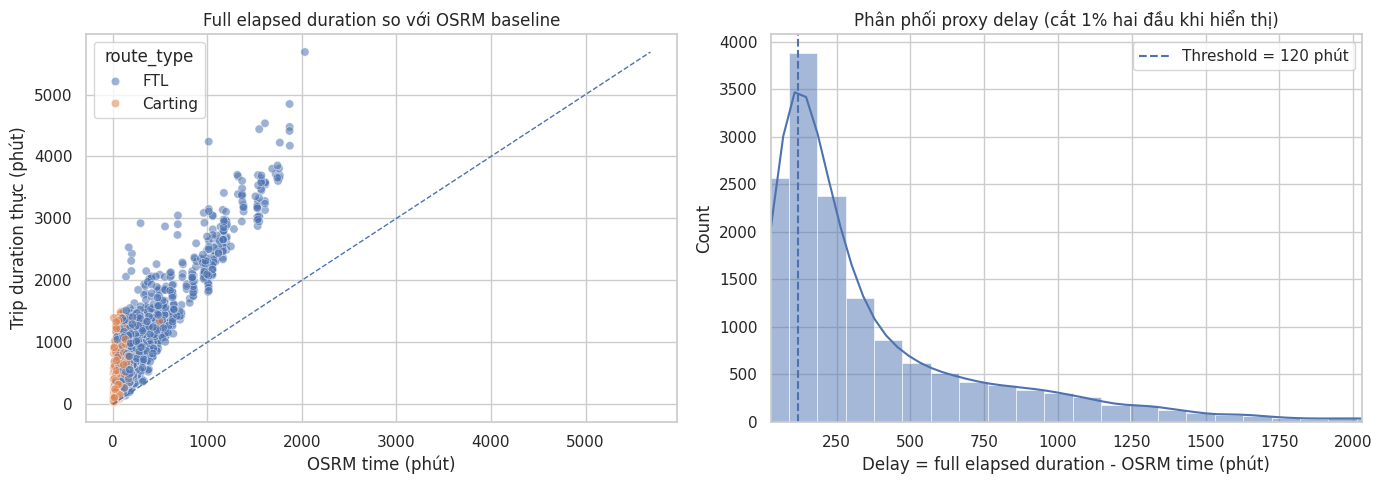

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sample = trip_df.sample(min(5000, len(trip_df)), random_state=RANDOM_STATE)
sns.scatterplot(
    data=sample, x='osrm_time', y='trip_duration_minutes',
    hue='route_type', alpha=.55, ax=axes[0]
)
max_time = max(sample['osrm_time'].max(), sample['trip_duration_minutes'].max())
axes[0].plot([0, max_time], [0, max_time], linestyle='--', linewidth=1)
axes[0].set_title('Full elapsed duration so với OSRM baseline')
axes[0].set_xlabel('OSRM time (phút)')
axes[0].set_ylabel('Trip duration thực (phút)')

sns.histplot(trip_df['delay_minutes'], bins=80, kde=True, ax=axes[1], color='C0')
axes[1].axvline(
    DELAY_THRESHOLD_MINUTES, linestyle='--',
    label=f'Threshold = {DELAY_THRESHOLD_MINUTES} phút'
)
axes[1].set_xlim(trip_df['delay_minutes'].quantile(.01), trip_df['delay_minutes'].quantile(.99))
axes[1].set_title('Phân phối proxy delay (cắt 1% hai đầu khi hiển thị)')
axes[1].set_xlabel('Delay = full elapsed duration - OSRM time (phút)')
axes[1].legend()

plt.tight_layout()
plt.show()

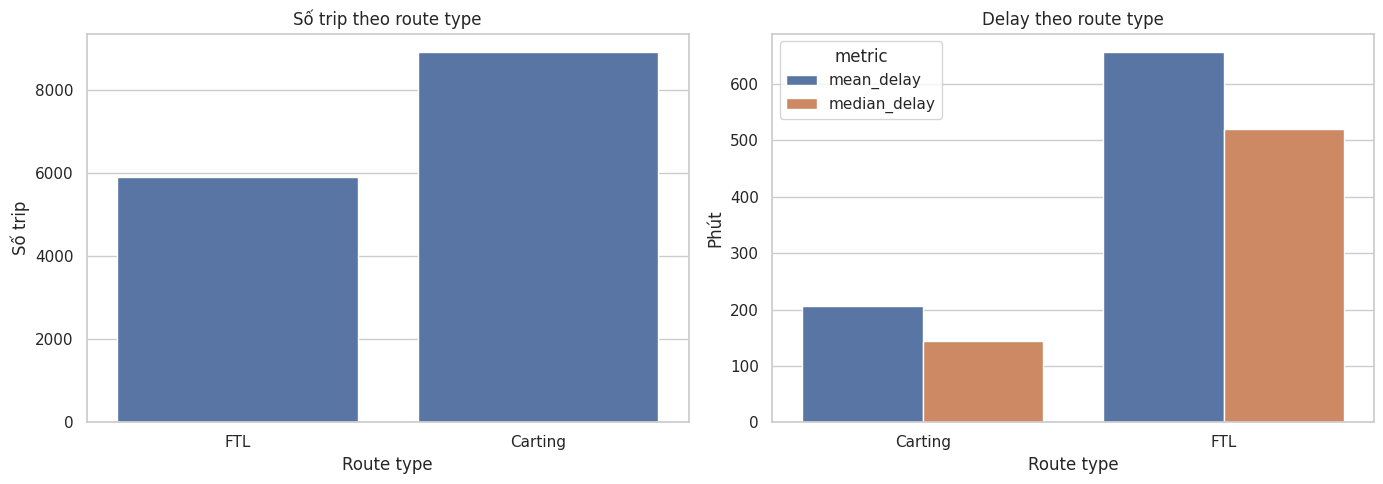

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=trip_df, x='route_type', ax=axes[0], color='C0')
axes[0].set_title('Số trip theo route type')
axes[0].set_xlabel('Route type')
axes[0].set_ylabel('Số trip')

route_delay = (
    trip_df.groupby('route_type', as_index=False)
           .agg(mean_delay=('delay_minutes', 'mean'), median_delay=('delay_minutes', 'median'))
)
route_delay_melt = route_delay.melt('route_type', var_name='metric', value_name='delay_minutes')
sns.barplot(data=route_delay_melt, x='route_type', y='delay_minutes', hue='metric', ax=axes[1], palette='deep')
axes[1].set_title('Delay theo route type')
axes[1].set_xlabel('Route type')
axes[1].set_ylabel('Phút')

plt.tight_layout()
plt.show()

,state_corridor,trips,mean_delay,median_delay,mean_trip_duration
0,Punjab → Karnataka,20,"2,033.478","2,034.250","3,782.328"
1,Haryana → Telangana,26,"1,808.370","1,928.518","3,116.831"
2,Karnataka → Haryana,38,"1,673.450","1,658.819","3,226.345"
3,Haryana → Karnataka,47,"1,572.965","1,517.846","3,116.093"
4,Haryana → West Bengal,32,"1,457.948","1,356.263","2,473.885"
5,West Bengal → Haryana,26,"1,394.229","1,398.169","2,481.421"
6,Delhi → Maharashtra,37,"1,231.963","1,186.976","2,257.314"
7,Gujarat → Karnataka,20,"1,227.181","1,211.308","2,201.731"
8,Haryana → Maharashtra,22,"1,203.878","1,160.248","2,172.741"
9,Maharashtra → Haryana,44,"1,114.545","1,129.711","2,101.681"


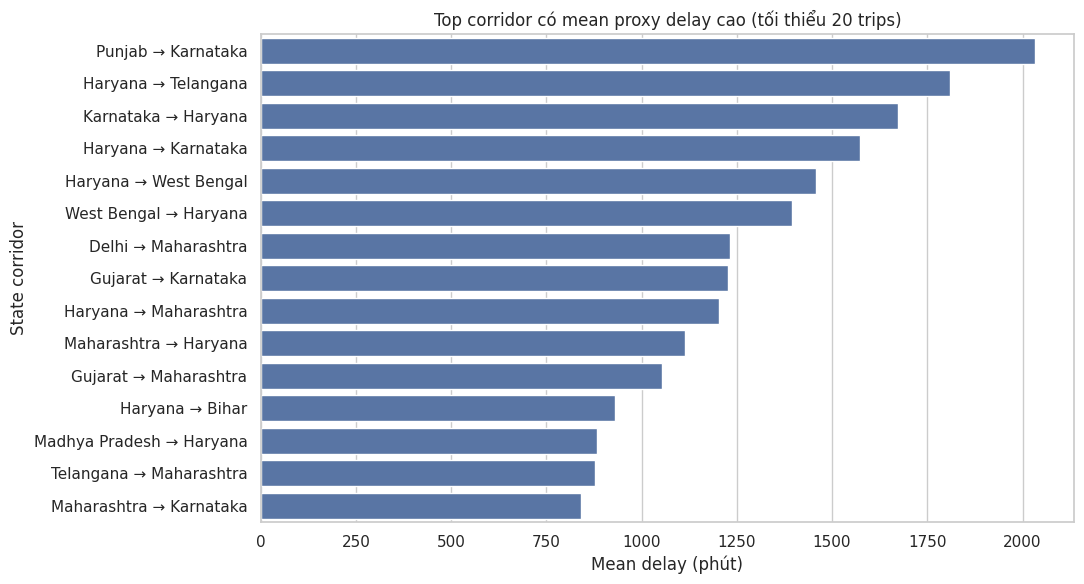

In [18]:
trip_df['state_corridor'] = trip_df['source_state'] + ' → ' + trip_df['destination_state']

corridor_summary = (
    trip_df.groupby('state_corridor')
           .agg(
               trips=('trip_uuid', 'size'),
               mean_delay=('delay_minutes', 'mean'),
               median_delay=('delay_minutes', 'median'),
               mean_trip_duration=('trip_duration_minutes', 'mean'),
           )
           .query('trips >= 20')
           .sort_values('mean_delay', ascending=False)
           .head(15)
           .reset_index()
)

display(corridor_summary)

plt.figure(figsize=(11, 6))
sns.barplot(data=corridor_summary, x='mean_delay', y='state_corridor', color='C0')
plt.title('Top corridor có mean proxy delay cao (tối thiểu 20 trips)')
plt.xlabel('Mean delay (phút)')
plt.ylabel('State corridor')
plt.tight_layout()
plt.show()

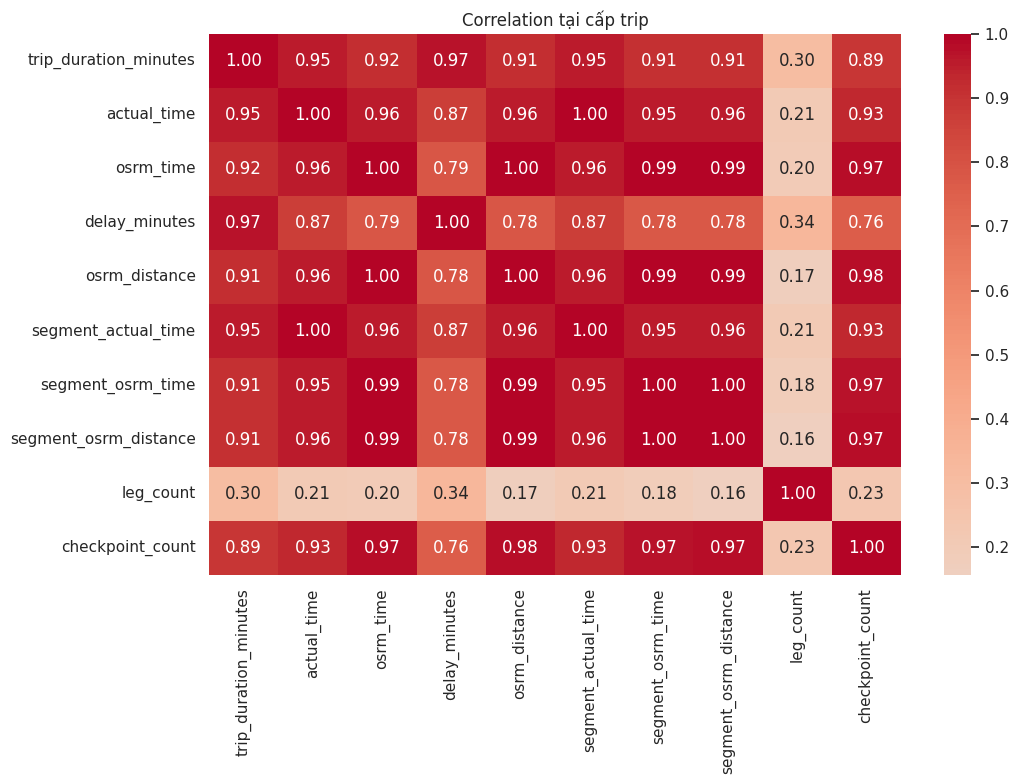

In [19]:
corr_cols = [
    'trip_duration_minutes', 'actual_time', 'osrm_time', 'delay_minutes',
    'osrm_distance', 'segment_actual_time', 'segment_osrm_time',
    'segment_osrm_distance', 'leg_count', 'checkpoint_count'
]
plt.figure(figsize=(11, 8))
sns.heatmap(trip_df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation tại cấp trip')
plt.tight_layout()
plt.show()

## 7. Feature Engineering


### Features for the Start-of-Trip Model

Only information guaranteed to be available before or at departure is used:

- the route plan's `osrm_time`, `osrm_distance`;
- origin, destination, and route type;
- departure hour/day;
- ratios computed only from the OSRM plan.

`segment_osrm_*`, `leg_count`, and `checkpoint_count` are not used because they are aggregated from all actual rows and may not be fully known at departure. No actual/cutoff/end-time variable is used.


In [20]:
trip_df['start_hour'] = trip_df['trip_start_time'].dt.hour
trip_df['start_dayofweek'] = trip_df['trip_start_time'].dt.dayofweek
trip_df['start_month'] = trip_df['trip_start_time'].dt.month
trip_df['is_weekend'] = trip_df['start_dayofweek'].isin([5, 6]).astype(int)
trip_df['state_corridor'] = trip_df['source_state'] + ' → ' + trip_df['destination_state']

trip_df['planned_speed_kmph'] = (
    trip_df['osrm_distance'] / (trip_df['osrm_time'] / 60).replace(0, np.nan)
)
trip_df['planned_minutes_per_km'] = (
    trip_df['osrm_time'] / trip_df['osrm_distance'].replace(0, np.nan)
)
trip_df = trip_df.replace([np.inf, -np.inf], np.nan)

START_NUMERIC_FEATURES = [
    'osrm_time', 'osrm_distance',
    'start_hour', 'start_dayofweek', 'start_month', 'is_weekend',
    'planned_speed_kmph', 'planned_minutes_per_km',
]

START_CATEGORICAL_FEATURES = [
    'route_type', 'source_state', 'destination_state', 'state_corridor'
]

START_FEATURES = START_NUMERIC_FEATURES + START_CATEGORICAL_FEATURES

print(f'Number of start-of-trip model features: {len(START_FEATURES)}')
display(trip_df[START_FEATURES + ['trip_duration_minutes', 'delay_minutes']].head())

Number of start-of-trip model features: 12


,osrm_time,osrm_distance,start_hour,start_dayofweek,start_month,is_weekend,planned_speed_kmph,planned_minutes_per_km,route_type,source_state,destination_state,state_corridor,trip_duration_minutes,delay_minutes
0,743.000,991.352,0,2,9,0,80.055,0.749,FTL,Madhya Pradesh,Haryana,Madhya Pradesh → Haryana,"2,260.110","1,517.110"
1,68.000,85.111,0,2,9,0,75.098,0.799,Carting,Karnataka,Karnataka,Karnataka → Karnataka,181.612,113.612
2,"1,741.000","2,372.085",0,2,9,0,81.749,0.734,FTL,Karnataka,Punjab,Karnataka → Punjab,"3,934.363","2,193.363"
3,15.000,19.680,0,2,9,0,78.720,0.762,Carting,Maharashtra,Maharashtra,Maharashtra → Maharashtra,100.495,85.495
4,117.000,146.792,0,2,9,0,75.278,0.797,FTL,Karnataka,Karnataka,Karnataka → Karnataka,718.349,601.349


## 8. Data Splitting and Leakage Prevention


The dataset has a built-in external time-based split:

- `training`: the earlier period;
- `test`: the later period.

The final test set is kept intact and used **only once**, after the model has been selected. Within `training`, the notebook creates an additional chronological 80/20 fit/validation split to compare models and choose the classification threshold.


In [21]:
train_df = trip_df.query("data == 'training'").copy().sort_values('trip_creation_time')
test_df = trip_df.query("data == 'test'").copy().sort_values('trip_creation_time')

trip_overlap = set(train_df['trip_uuid']).intersection(test_df['trip_uuid'])
assert len(trip_overlap) == 0, 'Có trip_uuid trùng giữa external train và test.'

validation_start = int(len(train_df) * 0.80)
fit_df = train_df.iloc[:validation_start].copy()
validation_df = train_df.iloc[validation_start:].copy()

fit_val_overlap = set(fit_df['trip_uuid']).intersection(validation_df['trip_uuid'])
assert len(fit_val_overlap) == 0, 'Có trip_uuid trùng giữa fit và validation.'
assert fit_df['trip_creation_time'].max() <= validation_df['trip_creation_time'].min()

split_summary = pd.DataFrame({
    'split': ['fit', 'validation', 'final test'],
    'n_trips': [len(fit_df), len(validation_df), len(test_df)],
    'pct_all_trips': [len(fit_df)/len(trip_df), len(validation_df)/len(trip_df), len(test_df)/len(trip_df)],
    'start_date': [
        fit_df['trip_creation_time'].min(), validation_df['trip_creation_time'].min(),
        test_df['trip_creation_time'].min()
    ],
    'end_date': [
        fit_df['trip_creation_time'].max(), validation_df['trip_creation_time'].max(),
        test_df['trip_creation_time'].max()
    ],
    'mean_duration': [
        fit_df['trip_duration_minutes'].mean(), validation_df['trip_duration_minutes'].mean(),
        test_df['trip_duration_minutes'].mean()
    ],
    'mean_delay': [fit_df['delay_minutes'].mean(), validation_df['delay_minutes'].mean(), test_df['delay_minutes'].mean()],
})

display(split_summary)
print(f'External train trips: {len(train_df):,} ({len(train_df)/len(trip_df):.2%})')
print(f'Final test trips: {len(test_df):,} ({len(test_df)/len(trip_df):.2%})')
print(f'Trip overlap external train/test: {len(trip_overlap)}')

,split,n_trips,pct_all_trips,start_date,end_date,mean_duration,mean_delay
0,fit,8523,0.575,2018-09-12 00:00:16.535741,2018-09-23 22:15:46.635975,545.265,382.142
1,validation,2131,0.144,2018-09-23 22:16:47.064680,2018-09-26 23:54:27.945614,570.765,399.243
2,final test,4163,0.281,2018-09-27 00:02:18.970980,2018-10-03 23:59:42.701692,540.085,384.998


External train trips: 10,654 (71.90%)
Final test trips: 4,163 (28.10%)
Trip overlap external train/test: 0


### Leakage Guard

The following columns **must not be fed into the start-of-trip ETA model**:

- `actual_time`, `segment_actual_time`, `actual_distance_to_destination`;
- `factor`, `segment_factor`, because they are derived directly from actual/planned time;
- `od_end_time`, `trip_end_time`, `start_scan_to_end_scan`;
- `cutoff_timestamp`, `cutoff_factor`, `cutoff_rate`, if predicting before the trip starts;
- `delay_minutes`, `actual_eta`, because they are the target or derived from the target.


In [22]:
LEAKAGE_COLUMNS = {
    'actual_time', 'segment_actual_time', 'actual_distance_to_destination',
    'factor', 'segment_factor', 'od_end_time', 'trip_end_time',
    'start_scan_to_end_scan', 'cutoff_timestamp', 'cutoff_factor',
    'cutoff_rate', 'delay_minutes', 'delay_ratio', 'actual_eta',
    'trip_duration_minutes', 'actual_time_gap_vs_elapsed',
    'segment_osrm_time', 'segment_osrm_distance', 'leg_count', 'checkpoint_count'
}

leaked = LEAKAGE_COLUMNS.intersection(START_FEATURES)
assert not leaked, f'Feature set chứa biến leakage/future information: {leaked}'
print('Start-of-trip leakage check passed.')

Start-of-trip leakage check passed.


In [23]:
def make_start_preprocessor():
    return ColumnTransformer(
        transformers=[
            ('numeric', Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
            ]), START_NUMERIC_FEATURES),
            ('categorical', Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(
                    handle_unknown='ignore',
                    min_frequency=10,
                    sparse_output=True,
                )),
            ]), START_CATEGORICAL_FEATURES),
        ],
        remainder='drop',
    )


@dataclass(frozen=True)
class ModelSpec:
    name: str
    group: str
    factory: Callable[[], BaseEstimator]
    matrix_kind: str = 'sparse'
    optional_dependency: Optional[str] = None
    note: str = ''


def optional_dependency_available(name):
    if name is None:
        return True, ''
    return OPTIONAL_DEPENDENCIES.get(name, (False, f'Unknown dependency: {name}'))


def make_adaboost_regressor():
    base = DecisionTreeRegressor(
        max_depth=3,
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
    )
    kwargs = dict(
        n_estimators=180,
        learning_rate=0.04,
        loss='square',
        random_state=RANDOM_STATE,
    )
    try:
        return AdaBoostRegressor(estimator=base, **kwargs)
    except TypeError:
        return AdaBoostRegressor(base_estimator=base, **kwargs)


def make_adaboost_classifier():
    base = DecisionTreeClassifier(
        max_depth=2,
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
    )
    kwargs = dict(
        n_estimators=180,
        learning_rate=0.04,
        random_state=RANDOM_STATE,
    )
    try:
        return AdaBoostClassifier(estimator=base, **kwargs)
    except TypeError:
        return AdaBoostClassifier(base_estimator=base, **kwargs)


def make_calibrated_classifier(base_estimator):
    """Bổ sung predict_proba cho model chỉ có decision_function."""
    try:
        return CalibratedClassifierCV(estimator=base_estimator, method='sigmoid', cv=3)
    except TypeError:
        return CalibratedClassifierCV(base_estimator=base_estimator, method='sigmoid', cv=3)


def make_ransac_regressor():
    kwargs = dict(
        min_samples=0.5,
        max_trials=100,
        loss='absolute_error',
        random_state=RANDOM_STATE,
    )
    try:
        return RANSACRegressor(estimator=LinearRegression(), **kwargs)
    except TypeError:
        return RANSACRegressor(base_estimator=LinearRegression(), **kwargs)


def make_bart_regressor():
    if BART_BACKEND == 'ISLP':
        return BART_CLASS(
            random_state=RANDOM_STATE,
            burnin=15,
            ndraw=30,
        )
    if BART_BACKEND == 'bartpy':
        return BART_CLASS(
            n_trees=50,
            n_samples=80,
            n_burn=50,
            n_jobs=N_JOBS,
        )
    raise ImportError('Không có backend BART. Cài ISLP hoặc bartpy.')


def regression_model_specs():

    return [
        ModelSpec('Decision Tree Regressor', 'Existing Trees', lambda: DecisionTreeRegressor(
            max_depth=14, min_samples_leaf=3, random_state=RANDOM_STATE)),
        ModelSpec('Random Forest Regressor', 'Existing Trees', lambda: RandomForestRegressor(
            n_estimators=180, max_depth=16, min_samples_leaf=2,
            max_features='sqrt', n_jobs=N_JOBS, random_state=RANDOM_STATE)),
        ModelSpec('Extra Trees Regressor', 'Existing Trees', lambda: ExtraTreesRegressor(
            n_estimators=180, max_depth=None, min_samples_leaf=2,
            max_features=1.0, n_jobs=N_JOBS, random_state=RANDOM_STATE)),
        ModelSpec('AdaBoost Regressor', 'Existing Trees', make_adaboost_regressor, matrix_kind='dense'),

        ModelSpec('Gradient Boosting Regressor', '1. Gradient Boosting', lambda: GradientBoostingRegressor(
            n_estimators=220, learning_rate=0.04, max_depth=3,
            min_samples_leaf=5, subsample=0.85, random_state=RANDOM_STATE), matrix_kind='dense'),
        ModelSpec('HistGradientBoosting Regressor', '1. Gradient Boosting', lambda: HistGradientBoostingRegressor(
            max_iter=240, learning_rate=0.05, max_leaf_nodes=31,
            l2_regularization=1.0, early_stopping=True, random_state=RANDOM_STATE), matrix_kind='dense'),
        ModelSpec('XGBoost Regressor', '1. Gradient Boosting', lambda: XGBRegressor(
            n_estimators=320, max_depth=5, learning_rate=0.05,
            subsample=0.85, colsample_bytree=0.85, objective='reg:squarederror',
            eval_metric='mae', tree_method='hist', n_jobs=N_JOBS, random_state=RANDOM_STATE)),
        ModelSpec('LightGBM Regressor', '1. Gradient Boosting', lambda: LGBMRegressor(
            n_estimators=320, learning_rate=0.04, num_leaves=31,
            subsample=0.85, colsample_bytree=0.85, reg_lambda=1.0,
            random_state=RANDOM_STATE, n_jobs=N_JOBS, verbosity=-1),
            optional_dependency='lightgbm'),
        ModelSpec('CatBoost Regressor', '1. Gradient Boosting', lambda: CatBoostRegressor(
            iterations=320, depth=6, learning_rate=0.04,
            loss_function='RMSE', random_seed=RANDOM_STATE, verbose=False,
            allow_writing_files=False, thread_count=N_JOBS),
            optional_dependency='catboost'),
        ModelSpec('NGBoost Regressor', '1. Gradient Boosting', lambda: NGBRegressor(
            n_estimators=220, learning_rate=0.03,
            verbose=False, random_state=RANDOM_STATE), matrix_kind='dense',
            optional_dependency='ngboost',
            note='Probabilistic boosting; huấn luyện trên toàn bộ fit.'),
        ModelSpec('Explainable Boosting Machine Regressor', '1. Gradient Boosting',
            lambda: ExplainableBoostingRegressor(
                max_rounds=1200, interactions=10,
                random_state=RANDOM_STATE, n_jobs=N_JOBS),
            matrix_kind='dense', optional_dependency='interpret',
            note='Explainable Boosting Machine; huấn luyện trên toàn bộ fit.'),
        ModelSpec('BART / GBART Regressor', '1. Gradient Boosting', make_bart_regressor,
            matrix_kind='dense', optional_dependency='bart',
            note='Bayesian Additive Regression Trees; rất nặng.'),
        ModelSpec('DART Regressor', '1. Gradient Boosting', lambda: XGBRegressor(
            booster='dart', n_estimators=260, max_depth=5,
            learning_rate=0.05, subsample=0.85, colsample_bytree=0.85,
            rate_drop=0.10, skip_drop=0.0, objective='reg:squarederror',
            eval_metric='mae', tree_method='hist', n_jobs=N_JOBS,
            random_state=RANDOM_STATE)),

        ModelSpec('SVR', '2. SVM', lambda: SVR(C=10.0, epsilon=0.1, kernel='rbf', gamma='scale'),
            note='Kernel SVR; huấn luyện trên toàn bộ fit.'),
        ModelSpec('LinearSVR', '2. SVM', lambda: LinearSVR(
            C=1.0, epsilon=0.1, max_iter=5000, random_state=RANDOM_STATE)),
        ModelSpec('NuSVR', '2. SVM', lambda: NuSVR(C=10.0, nu=0.5, kernel='rbf', gamma='scale'),
            note='Kernel NuSVR; huấn luyện trên toàn bộ fit.'),

        ModelSpec('Linear Regression', '3. Linear Models', lambda: LinearRegression(n_jobs=N_JOBS)),
        ModelSpec('Ridge Regression', '3. Linear Models', lambda: Ridge(alpha=10.0, solver='lsqr')),
        ModelSpec('Lasso Regression', '3. Linear Models', lambda: Lasso(
            alpha=0.01, max_iter=5000, random_state=RANDOM_STATE)),
        ModelSpec('Elastic Net', '3. Linear Models', lambda: ElasticNet(
            alpha=0.01, l1_ratio=0.5, max_iter=5000, random_state=RANDOM_STATE)),
        ModelSpec('Bayesian Ridge', '3. Linear Models', lambda: BayesianRidge(), matrix_kind='dense'),
        ModelSpec('ARD Regression', '3. Linear Models', lambda: ARDRegression(), matrix_kind='dense'),
        ModelSpec('Huber Regressor', '3. Linear Models', lambda: HuberRegressor(
            epsilon=1.35, alpha=0.0001, max_iter=500), matrix_kind='dense', note='Huấn luyện trên toàn bộ fit.'),
        ModelSpec('Theil-Sen Regressor', '3. Linear Models', lambda: TheilSenRegressor(
            max_subpopulation=10000, n_jobs=N_JOBS,
            random_state=RANDOM_STATE), matrix_kind='dense', note='Estimator robust; huấn luyện trên toàn bộ fit.'),
        ModelSpec('RANSAC Regressor', '3. Linear Models', make_ransac_regressor,
            matrix_kind='dense',
            note='Huấn luyện trên toàn bộ fit.'),
        ModelSpec('Quantile Regression', '3. Linear Models', lambda: QuantileRegressor(
            quantile=0.5, alpha=0.01, solver='highs'), matrix_kind='dense',
            note='Quantile regression bằng linear programming; huấn luyện trên toàn bộ fit.'),
        ModelSpec('Poisson Regressor', '3. Linear Models', lambda: PoissonRegressor(
            alpha=1.0, max_iter=500), matrix_kind='dense'),
        ModelSpec('Gamma Regressor', '3. Linear Models', lambda: GammaRegressor(
            alpha=1.0, max_iter=500), matrix_kind='dense'),
        ModelSpec('Tweedie Regressor', '3. Linear Models', lambda: TweedieRegressor(
            power=1.5, alpha=1.0, max_iter=500), matrix_kind='dense'),
        ModelSpec('SGD Regressor', '3. Linear Models', lambda: SGDRegressor(
            loss='huber', penalty='elasticnet', alpha=0.0001, max_iter=3000,
            early_stopping=True, random_state=RANDOM_STATE)),
        ModelSpec('Passive Aggressive Regressor', '3. Linear Models', lambda: PassiveAggressiveRegressor(
            C=0.1, max_iter=3000, early_stopping=True, random_state=RANDOM_STATE)),
    ]


def classification_model_specs():

    return [
        ModelSpec('Decision Tree Classifier', 'Existing Trees', lambda: DecisionTreeClassifier(
            max_depth=12, min_samples_leaf=4, random_state=RANDOM_STATE)),
        ModelSpec('Random Forest Classifier', 'Existing Trees', lambda: RandomForestClassifier(
            n_estimators=180, max_depth=14, min_samples_leaf=3,
            max_features='sqrt', n_jobs=N_JOBS, random_state=RANDOM_STATE)),
        ModelSpec('Extra Trees Classifier', 'Existing Trees', lambda: ExtraTreesClassifier(
            n_estimators=180, max_depth=None, min_samples_leaf=3,
            max_features=1.0, n_jobs=N_JOBS, random_state=RANDOM_STATE)),
        ModelSpec('AdaBoost Classifier', 'Existing Trees', make_adaboost_classifier, matrix_kind='dense'),

        ModelSpec('Gradient Boosting Classifier', '1. Gradient Boosting', lambda: GradientBoostingClassifier(
            n_estimators=220, learning_rate=0.04, max_depth=3,
            min_samples_leaf=5, subsample=0.85, random_state=RANDOM_STATE), matrix_kind='dense'),
        ModelSpec('HistGradientBoosting Classifier', '1. Gradient Boosting', lambda: HistGradientBoostingClassifier(
            max_iter=240, learning_rate=0.05, max_leaf_nodes=31,
            l2_regularization=1.0, early_stopping=True, random_state=RANDOM_STATE), matrix_kind='dense'),
        ModelSpec('XGBoost Classifier', '1. Gradient Boosting', lambda: XGBClassifier(
            n_estimators=300, max_depth=5, learning_rate=0.05,
            subsample=0.85, colsample_bytree=0.85, objective='binary:logistic',
            eval_metric='logloss', tree_method='hist', n_jobs=N_JOBS,
            random_state=RANDOM_STATE)),
        ModelSpec('LightGBM Classifier', '1. Gradient Boosting', lambda: LGBMClassifier(
            n_estimators=300, learning_rate=0.04, num_leaves=31,
            subsample=0.85, colsample_bytree=0.85, reg_lambda=1.0,
            random_state=RANDOM_STATE, n_jobs=N_JOBS, verbosity=-1),
            optional_dependency='lightgbm'),
        ModelSpec('CatBoost Classifier', '1. Gradient Boosting', lambda: CatBoostClassifier(
            iterations=300, depth=6, learning_rate=0.04,
            loss_function='Logloss', random_seed=RANDOM_STATE, verbose=False,
            allow_writing_files=False, thread_count=N_JOBS),
            optional_dependency='catboost'),
        ModelSpec('NGBoost Classifier', '1. Gradient Boosting', lambda: NGBClassifier(
            n_estimators=220, learning_rate=0.03,
            verbose=False, random_state=RANDOM_STATE), matrix_kind='dense',
            optional_dependency='ngboost', note='Probabilistic boosting; huấn luyện trên toàn bộ fit.'),
        ModelSpec('Explainable Boosting Machine Classifier', '1. Gradient Boosting',
            lambda: ExplainableBoostingClassifier(
                max_rounds=1200, interactions=10,
                random_state=RANDOM_STATE, n_jobs=N_JOBS),
            matrix_kind='dense', optional_dependency='interpret', note='Explainable Boosting Machine; huấn luyện trên toàn bộ fit.'),
        ModelSpec('DART Classifier', '1. Gradient Boosting', lambda: XGBClassifier(
            booster='dart', n_estimators=260, max_depth=5,
            learning_rate=0.05, subsample=0.85, colsample_bytree=0.85,
            rate_drop=0.10, skip_drop=0.0, objective='binary:logistic',
            eval_metric='logloss', tree_method='hist', n_jobs=N_JOBS,
            random_state=RANDOM_STATE)),

        ModelSpec('SVC', '2. SVM', lambda: SVC(
            C=5.0, kernel='rbf', gamma='scale', probability=True,
            random_state=RANDOM_STATE), note='Kernel SVC với probability=True; huấn luyện trên toàn bộ fit.'),
        ModelSpec('LinearSVC', '2. SVM', lambda: make_calibrated_classifier(LinearSVC(
            C=1.0, max_iter=5000, random_state=RANDOM_STATE))),
        ModelSpec('NuSVC', '2. SVM', lambda: NuSVC(
            nu=0.5, kernel='rbf', gamma='scale', probability=True,
            random_state=RANDOM_STATE), note='Kernel NuSVC với probability=True; huấn luyện trên toàn bộ fit.'),

        ModelSpec('Logistic Regression', '3. Linear Models', lambda: LogisticRegression(
            C=1.0, max_iter=3000, solver='liblinear', random_state=RANDOM_STATE)),
        ModelSpec('SGD Classifier', '3. Linear Models', lambda: SGDClassifier(
            loss='log_loss', penalty='elasticnet', alpha=0.0001, max_iter=3000,
            early_stopping=True, random_state=RANDOM_STATE)),
        ModelSpec('Passive Aggressive Classifier', '3. Linear Models',
            lambda: make_calibrated_classifier(PassiveAggressiveClassifier(
                C=0.1, max_iter=3000, early_stopping=True,
                random_state=RANDOM_STATE))),
    ]


def prepare_model_matrix(X, matrix_kind):
    if matrix_kind == 'dense' and sparse.issparse(X):
        return X.toarray()
    return X


def safe_roc_auc(y_true, probability):
    return roc_auc_score(y_true, probability) if pd.Series(y_true).nunique() > 1 else np.nan


def positive_class_probability(model, X):
    if hasattr(model, 'predict_proba'):
        probability = np.asarray(model.predict_proba(X))
        if probability.ndim == 2:
            return probability[:, 1]
        return probability.reshape(-1)
    if hasattr(model, 'decision_function'):
        return expit(np.asarray(model.decision_function(X)).reshape(-1))
    return np.asarray(model.predict(X), dtype=float).reshape(-1)


def fit_classifier_with_balancing(model, X, y):
    sample_weight = compute_sample_weight(class_weight='balanced', y=y)
    try:
        model.fit(X, y, sample_weight=sample_weight)
        return model, True
    except (TypeError, ValueError) as exc:
        model.fit(X, y)
        return model, False




class SafeRadiusNeighborsRegressor(BaseEstimator, RegressorMixin):
    """Radius-neighbor regression; fallback sang KNN nếu query không có neighbor."""
    def __init__(self, radius=5.0, weights='distance', fallback_neighbors=25, n_jobs=None):
        self.radius = radius
        self.weights = weights
        self.fallback_neighbors = fallback_neighbors
        self.n_jobs = n_jobs

    def fit(self, X, y):
        self.radius_model_ = RadiusNeighborsRegressor(
            radius=self.radius, weights=self.weights, n_jobs=self.n_jobs
        ).fit(X, y)
        self.fallback_model_ = KNeighborsRegressor(
            n_neighbors=min(self.fallback_neighbors, len(y)),
            weights=self.weights,
            n_jobs=self.n_jobs,
        ).fit(X, y)
        self.n_features_in_ = X.shape[1]
        return self

    def predict(self, X):
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            pred = np.asarray(self.radius_model_.predict(X), dtype=float)
        invalid = ~np.isfinite(pred)
        if invalid.any():
            pred[invalid] = self.fallback_model_.predict(X[invalid])
        return pred


class SafeRadiusNeighborsClassifier(BaseEstimator, ClassifierMixin):
    """Radius-neighbor classification; fallback sang KNN cho outlier queries."""
    def __init__(self, radius=5.0, weights='distance', fallback_neighbors=25, n_jobs=None):
        self.radius = radius
        self.weights = weights
        self.fallback_neighbors = fallback_neighbors
        self.n_jobs = n_jobs

    def fit(self, X, y, sample_weight=None):
        self.radius_model_ = RadiusNeighborsClassifier(
            radius=self.radius,
            weights=self.weights,
            outlier_label='most_frequent',
            n_jobs=self.n_jobs,
        ).fit(X, y)
        self.fallback_model_ = KNeighborsClassifier(
            n_neighbors=min(self.fallback_neighbors, len(y)),
            weights=self.weights,
            n_jobs=self.n_jobs,
        ).fit(X, y)
        self.classes_ = self.radius_model_.classes_
        self.n_features_in_ = X.shape[1]
        return self

    def _outlier_mask(self, X):
        neighbors = self.radius_model_.radius_neighbors(X, return_distance=False)
        return np.fromiter((len(x) == 0 for x in neighbors), dtype=bool, count=len(neighbors))

    def predict_proba(self, X):
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            proba = np.asarray(self.radius_model_.predict_proba(X), dtype=float)
        outlier = self._outlier_mask(X)
        if outlier.any():
            proba[outlier] = self.fallback_model_.predict_proba(X[outlier])
        return proba

    def predict(self, X):
        return self.classes_[np.argmax(self.predict_proba(X), axis=1)]


class ShiftedMultinomialNB(BaseEstimator, ClassifierMixin):
    """MultinomialNB wrapper để xử lý feature đã standardize có giá trị âm."""
    def __init__(self, alpha=1.0):
        self.alpha = alpha

    def _transform(self, X):
        X = X.toarray() if sparse.issparse(X) else np.asarray(X, dtype=float)
        return np.maximum(X + self.shift_, 0.0)

    def fit(self, X, y, sample_weight=None):
        X = X.toarray() if sparse.issparse(X) else np.asarray(X, dtype=float)
        self.shift_ = np.maximum(-np.nanmin(X, axis=0), 0.0)
        self.model_ = MultinomialNB(alpha=self.alpha)
        self.model_.fit(np.maximum(X + self.shift_, 0.0), y, sample_weight=sample_weight)
        self.classes_ = self.model_.classes_
        self.n_features_in_ = X.shape[1]
        return self

    def predict_proba(self, X):
        return self.model_.predict_proba(self._transform(X))

    def predict(self, X):
        return self.model_.predict(self._transform(X))


class RotationForestRegressor(BaseEstimator, RegressorMixin):
    """Rotation Forest regression: PCA rotations theo nhóm feature + Decision Trees."""
    def __init__(self, n_estimators=30, n_feature_subsets=5, sample_fraction=0.75,
                 min_samples_leaf=2, random_state=None):
        self.n_estimators = n_estimators
        self.n_feature_subsets = n_feature_subsets
        self.sample_fraction = sample_fraction
        self.min_samples_leaf = min_samples_leaf
        self.random_state = random_state

    def _rotate(self, X, rotations):
        X_rot = np.empty_like(X, dtype=float)
        for indices, pca in rotations:
            X_rot[:, indices] = pca.transform(X[:, indices])
        return X_rot

    def fit(self, X, y):
        X = X.toarray() if sparse.issparse(X) else np.asarray(X, dtype=float)
        y = np.asarray(y)
        rng = np.random.RandomState(self.random_state)
        self.estimators_ = []
        self.rotations_ = []
        self.n_features_in_ = X.shape[1]
        subset_count = max(1, min(self.n_feature_subsets, X.shape[1]))
        sample_size = min(len(y), max(X.shape[1] + 1, int(self.sample_fraction * len(y))))

        for _ in range(self.n_estimators):
            groups = np.array_split(rng.permutation(X.shape[1]), subset_count)
            rotations = []
            X_rot = np.empty_like(X, dtype=float)
            for indices in groups:
                rows = rng.choice(len(y), size=sample_size, replace=False)
                pca = PCA(n_components=len(indices), random_state=rng.randint(0, 2**31 - 1))
                pca.fit(X[np.ix_(rows, indices)])
                X_rot[:, indices] = pca.transform(X[:, indices])
                rotations.append((indices, pca))
            tree = DecisionTreeRegressor(
                min_samples_leaf=self.min_samples_leaf,
                random_state=rng.randint(0, 2**31 - 1),
            ).fit(X_rot, y)
            self.rotations_.append(rotations)
            self.estimators_.append(tree)
        return self

    def predict(self, X):
        X = X.toarray() if sparse.issparse(X) else np.asarray(X, dtype=float)
        predictions = [tree.predict(self._rotate(X, rotations))
                       for tree, rotations in zip(self.estimators_, self.rotations_)]
        return np.mean(predictions, axis=0)


class RotationForestClassifier(BaseEstimator, ClassifierMixin):
    """Rotation Forest classification: PCA rotations theo nhóm feature + Decision Trees."""
    def __init__(self, n_estimators=30, n_feature_subsets=5, sample_fraction=0.75,
                 min_samples_leaf=2, random_state=None):
        self.n_estimators = n_estimators
        self.n_feature_subsets = n_feature_subsets
        self.sample_fraction = sample_fraction
        self.min_samples_leaf = min_samples_leaf
        self.random_state = random_state

    def _rotate(self, X, rotations):
        X_rot = np.empty_like(X, dtype=float)
        for indices, pca in rotations:
            X_rot[:, indices] = pca.transform(X[:, indices])
        return X_rot

    def fit(self, X, y, sample_weight=None):
        X = X.toarray() if sparse.issparse(X) else np.asarray(X, dtype=float)
        y = np.asarray(y)
        rng = np.random.RandomState(self.random_state)
        self.classes_ = np.unique(y)
        self.estimators_ = []
        self.rotations_ = []
        self.n_features_in_ = X.shape[1]
        subset_count = max(1, min(self.n_feature_subsets, X.shape[1]))
        sample_size = min(len(y), max(X.shape[1] + 1, int(self.sample_fraction * len(y))))

        for _ in range(self.n_estimators):
            groups = np.array_split(rng.permutation(X.shape[1]), subset_count)
            rotations = []
            X_rot = np.empty_like(X, dtype=float)
            for indices in groups:
                rows = rng.choice(len(y), size=sample_size, replace=False)
                pca = PCA(n_components=len(indices), random_state=rng.randint(0, 2**31 - 1))
                pca.fit(X[np.ix_(rows, indices)])
                X_rot[:, indices] = pca.transform(X[:, indices])
                rotations.append((indices, pca))
            tree = DecisionTreeClassifier(
                min_samples_leaf=self.min_samples_leaf,
                random_state=rng.randint(0, 2**31 - 1),
            )
            tree.fit(X_rot, y, sample_weight=sample_weight)
            self.rotations_.append(rotations)
            self.estimators_.append(tree)
        return self

    def predict_proba(self, X):
        X = X.toarray() if sparse.issparse(X) else np.asarray(X, dtype=float)
        probabilities = [tree.predict_proba(self._rotate(X, rotations))
                         for tree, rotations in zip(self.estimators_, self.rotations_)]
        return np.mean(probabilities, axis=0)

    def predict(self, X):
        return self.classes_[np.argmax(self.predict_proba(X), axis=1)]


def make_bagging_regressor(max_features=1.0, bootstrap=True):
    base = DecisionTreeRegressor(min_samples_leaf=2, random_state=RANDOM_STATE)
    kwargs = dict(
        n_estimators=120,
        max_samples=1.0,
        max_features=max_features,
        bootstrap=bootstrap,
        bootstrap_features=False,
        n_jobs=N_JOBS,
        random_state=RANDOM_STATE,
    )
    try:
        return BaggingRegressor(estimator=base, **kwargs)
    except TypeError:
        return BaggingRegressor(base_estimator=base, **kwargs)


def make_bagging_classifier(max_features=1.0, bootstrap=True):
    base = DecisionTreeClassifier(min_samples_leaf=2, random_state=RANDOM_STATE)
    kwargs = dict(
        n_estimators=120,
        max_samples=1.0,
        max_features=max_features,
        bootstrap=bootstrap,
        bootstrap_features=False,
        n_jobs=N_JOBS,
        random_state=RANDOM_STATE,
    )
    try:
        return BaggingClassifier(estimator=base, **kwargs)
    except TypeError:
        return BaggingClassifier(base_estimator=base, **kwargs)


def make_easy_ensemble_classifier():
    base = AdaBoostClassifier(
        n_estimators=80,
        learning_rate=0.05,
        random_state=RANDOM_STATE,
    )
    kwargs = dict(
        n_estimators=20,
        sampling_strategy='auto',
        replacement=False,
        n_jobs=N_JOBS,
        random_state=RANDOM_STATE,
    )
    try:
        return EasyEnsembleClassifier(estimator=base, **kwargs)
    except TypeError:
        return EasyEnsembleClassifier(base_estimator=base, **kwargs)


def make_rusboost_classifier():
    base = DecisionTreeClassifier(max_depth=2, min_samples_leaf=4, random_state=RANDOM_STATE)
    kwargs = dict(
        n_estimators=180,
        learning_rate=0.05,
        sampling_strategy='auto',
        replacement=False,
        random_state=RANDOM_STATE,
    )
    try:
        return RUSBoostClassifier(estimator=base, **kwargs)
    except TypeError:
        return RUSBoostClassifier(base_estimator=base, **kwargs)


def new_regression_model_specs():
    return [
        ModelSpec('KNeighbors Regressor', '4. Nearest Neighbors', lambda: KNeighborsRegressor(
            n_neighbors=25, weights='distance', p=2, n_jobs=N_JOBS)),
        ModelSpec('RadiusNeighbors Regressor', '4. Nearest Neighbors', lambda: SafeRadiusNeighborsRegressor(
            radius=5.0, weights='distance', fallback_neighbors=25, n_jobs=N_JOBS)),
        ModelSpec('Bagging Regressor', '5. Bagging & Randomized Ensemble',
            lambda: make_bagging_regressor(max_features=1.0, bootstrap=True)),
        ModelSpec('Random Subspace Regressor', '5. Bagging & Randomized Ensemble',
            lambda: make_bagging_regressor(max_features=0.5, bootstrap=False)),
        ModelSpec('Rotation Forest Regressor', '5. Bagging & Randomized Ensemble',
            lambda: RotationForestRegressor(n_estimators=30, n_feature_subsets=5,
                sample_fraction=0.75, min_samples_leaf=2, random_state=RANDOM_STATE),
            matrix_kind='dense'),
        ModelSpec('Gaussian Process Regressor', '6. Probabilistic & Statistical Models',
            lambda: GaussianProcessRegressor(
                kernel=ConstantKernel(1.0) * RBF(1.0) + WhiteKernel(1.0),
                alpha=1e-6, normalize_y=True, optimizer=None,
                copy_X_train=False, random_state=RANDOM_STATE),
            matrix_kind='dense',
            note='Exact Gaussian Process trên toàn bộ fit; có thể cần RAM/thời gian rất lớn.'),
    ]


def new_classification_model_specs():
    return [
        ModelSpec('KNeighbors Classifier', '4. Nearest Neighbors', lambda: KNeighborsClassifier(
            n_neighbors=25, weights='distance', p=2, n_jobs=N_JOBS)),
        ModelSpec('RadiusNeighbors Classifier', '4. Nearest Neighbors', lambda: SafeRadiusNeighborsClassifier(
            radius=5.0, weights='distance', fallback_neighbors=25, n_jobs=N_JOBS)),
        ModelSpec('Bagging Classifier', '5. Bagging & Randomized Ensemble',
            lambda: make_bagging_classifier(max_features=1.0, bootstrap=True)),
        ModelSpec('Random Subspace Classifier', '5. Bagging & Randomized Ensemble',
            lambda: make_bagging_classifier(max_features=0.5, bootstrap=False)),
        ModelSpec('Rotation Forest Classifier', '5. Bagging & Randomized Ensemble',
            lambda: RotationForestClassifier(n_estimators=30, n_feature_subsets=5,
                sample_fraction=0.75, min_samples_leaf=2, random_state=RANDOM_STATE),
            matrix_kind='dense'),
        ModelSpec('Balanced Random Forest Classifier', '5. Bagging & Randomized Ensemble',
            lambda: BalancedRandomForestClassifier(
                n_estimators=180, max_depth=None, min_samples_leaf=2,
                max_features='sqrt', sampling_strategy='all', replacement=True,
                bootstrap=False, n_jobs=N_JOBS, random_state=RANDOM_STATE),
            optional_dependency='imbalanced_learn'),
        ModelSpec('Easy Ensemble Classifier', '5. Bagging & Randomized Ensemble',
            make_easy_ensemble_classifier, optional_dependency='imbalanced_learn'),
        ModelSpec('RUSBoost Classifier', '5. Bagging & Randomized Ensemble',
            make_rusboost_classifier, optional_dependency='imbalanced_learn'),
        ModelSpec('Gaussian Naive Bayes', '6. Probabilistic & Statistical Models',
            lambda: GaussianNB(var_smoothing=1e-9), matrix_kind='dense'),
        ModelSpec('Bernoulli Naive Bayes', '6. Probabilistic & Statistical Models',
            lambda: BernoulliNB(alpha=1.0, binarize=0.0)),
        ModelSpec('Multinomial Naive Bayes', '6. Probabilistic & Statistical Models',
            lambda: ShiftedMultinomialNB(alpha=1.0), matrix_kind='dense'),
        ModelSpec('Linear Discriminant Analysis (LDA)', '6. Probabilistic & Statistical Models',
            lambda: LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto'), matrix_kind='dense'),
        ModelSpec('Quadratic Discriminant Analysis (QDA)', '6. Probabilistic & Statistical Models',
            lambda: QuadraticDiscriminantAnalysis(reg_param=0.10), matrix_kind='dense'),
        ModelSpec('Gaussian Process Classifier', '6. Probabilistic & Statistical Models',
            lambda: GaussianProcessClassifier(
                kernel=ConstantKernel(1.0) * RBF(1.0), optimizer=None,
                max_iter_predict=100, copy_X_train=False,
                random_state=RANDOM_STATE),
            matrix_kind='dense',
            note='Exact Gaussian Process trên toàn bộ fit; có thể cần RAM/thời gian rất lớn.'),
    ]


OLD_REGRESSION_SPECS = regression_model_specs()
OLD_CLASSIFICATION_SPECS = classification_model_specs()
NEW_REGRESSION_SPECS = new_regression_model_specs()
NEW_CLASSIFICATION_SPECS = new_classification_model_specs()

REGRESSION_SPECS = OLD_REGRESSION_SPECS + NEW_REGRESSION_SPECS
CLASSIFICATION_SPECS = OLD_CLASSIFICATION_SPECS + NEW_CLASSIFICATION_SPECS

old_regression_names = {spec.name for spec in OLD_REGRESSION_SPECS}
old_classification_names = {spec.name for spec in OLD_CLASSIFICATION_SPECS}

model_inventory_df = pd.DataFrame([
    {
        'Task': 'Regression', 'Model': spec.name, 'Group': spec.group,
        'Matrix': spec.matrix_kind, 'Optional dependency': spec.optional_dependency,
        'v5.1 action': 'Không benchmark lại — dùng snapshot v5', 'Note': spec.note,
    }
    for spec in OLD_REGRESSION_SPECS
] + [
    {
        'Task': 'Regression', 'Model': spec.name, 'Group': spec.group,
        'Matrix': spec.matrix_kind, 'Optional dependency': spec.optional_dependency,
        'v5.1 action': 'Chạy mới trên toàn bộ chronological fit', 'Note': spec.note,
    }
    for spec in NEW_REGRESSION_SPECS
] + [
    {
        'Task': 'Classification', 'Model': spec.name, 'Group': spec.group,
        'Matrix': spec.matrix_kind, 'Optional dependency': spec.optional_dependency,
        'v5.1 action': 'Không benchmark lại — dùng snapshot v5', 'Note': spec.note,
    }
    for spec in OLD_CLASSIFICATION_SPECS
] + [
    {
        'Task': 'Classification', 'Model': spec.name, 'Group': spec.group,
        'Matrix': spec.matrix_kind, 'Optional dependency': spec.optional_dependency,
        'v5.1 action': 'Chạy mới trên toàn bộ chronological fit', 'Note': spec.note,
    }
    for spec in NEW_CLASSIFICATION_SPECS
])

print(f'Old regression snapshots: {len(OLD_REGRESSION_SPECS)}')
print(f'New regression models to run: {len(NEW_REGRESSION_SPECS)}')
print(f'Old classification snapshots: {len(OLD_CLASSIFICATION_SPECS)}')
print(f'New classification models to run: {len(NEW_CLASSIFICATION_SPECS)}')
display(model_inventory_df.style.set_caption('Model inventory — v5.1 incremental benchmark'))


Old regression snapshots: 31
New regression models to run: 6
Old classification snapshots: 18
New classification models to run: 14


,Task,Model,Group,Matrix,Optional dependency,v5.1 action,Note
0,Regression,Decision Tree Regressor,Existing Trees,sparse,None,Không benchmark lại — dùng snapshot v5,
1,Regression,Random Forest Regressor,Existing Trees,sparse,None,Không benchmark lại — dùng snapshot v5,
2,Regression,Extra Trees Regressor,Existing Trees,sparse,None,Không benchmark lại — dùng snapshot v5,
3,Regression,AdaBoost Regressor,Existing Trees,dense,None,Không benchmark lại — dùng snapshot v5,
4,Regression,Gradient Boosting Regressor,1. Gradient Boosting,dense,None,Không benchmark lại — dùng snapshot v5,
5,Regression,HistGradientBoosting Regressor,1. Gradient Boosting,dense,None,Không benchmark lại — dùng snapshot v5,
6,Regression,XGBoost Regressor,1. Gradient Boosting,sparse,None,Không benchmark lại — dùng snapshot v5,
7,Regression,LightGBM Regressor,1. Gradient Boosting,sparse,lightgbm,Không benchmark lại — dùng snapshot v5,
8,Regression,CatBoost Regressor,1. Gradient Boosting,sparse,catboost,Không benchmark lại — dùng snapshot v5,
9,Regression,NGBoost Regressor,1. Gradient Boosting,dense,ngboost,Không benchmark lại — dùng snapshot v5,Probabilistic boosting; huấn luyện trên toàn bộ fit.


## 9. ETA Regression — New Group 4–6 Run, Groups 1–3 Not Rerun


The v5 version already benchmarked 31 regressors. In v5.1:

- The old benchmark cell is replaced with a **static snapshot** of the previously run output.
- Decision Tree, Random Forest, Extra Trees, AdaBoost, Bayesian Ridge, and ARD already appear in the snapshot and are not rerun.
- Only 6 new regressors are trained on the same full chronological `fit_df`.
- The new leaderboard is merged with the old snapshot to select the best overall model.
- If an old model still leads, only that winning model is refit once on `train_df`; the 31-model benchmark is not rerun.


In [24]:

old_eta_validation_results_df = pd.DataFrame(json.loads(r'''[{"Model": "Extra Trees Regressor", "Group": "Existing Trees", "Status": "trained", "Reason": null, "Matrix": "sparse", "FitRows": 8523, "TrainingSeconds": 14.413871, "PredictionSeconds": 0.064379, "MAE": 101.735702, "MedianAE": 52.718286, "RMSE": 183.093811, "R2": 0.926177}, {"Model": "LightGBM Regressor", "Group": "1. Gradient Boosting", "Status": "trained", "Reason": null, "Matrix": "sparse", "FitRows": 8523, "TrainingSeconds": 0.365476, "PredictionSeconds": 0.020656, "MAE": 118.795026, "MedianAE": 70.172635, "RMSE": 195.304735, "R2": 0.916002}, {"Model": "HistGradientBoosting Regressor", "Group": "1. Gradient Boosting", "Status": "trained", "Reason": null, "Matrix": "dense", "FitRows": 8523, "TrainingSeconds": 2.556797, "PredictionSeconds": 0.07205, "MAE": 122.752979, "MedianAE": 74.589893, "RMSE": 198.236096, "R2": 0.913462}, {"Model": "XGBoost Regressor", "Group": "1. Gradient Boosting", "Status": "trained", "Reason": null, "Matrix": "sparse", "FitRows": 8523, "TrainingSeconds": 0.352171, "PredictionSeconds": 0.016634, "MAE": 122.790507, "MedianAE": 71.703115, "RMSE": 201.171372, "R2": 0.91088}, {"Model": "Decision Tree Regressor", "Group": "Existing Trees", "Status": "trained", "Reason": null, "Matrix": "sparse", "FitRows": 8523, "TrainingSeconds": 0.119837, "PredictionSeconds": 0.000779, "MAE": 127.588814, "MedianAE": 68.607032, "RMSE": 221.602043, "R2": 0.891859}, {"Model": "Random Forest Regressor", "Group": "Existing Trees", "Status": "trained", "Reason": null, "Matrix": "sparse", "FitRows": 8523, "TrainingSeconds": 1.679101, "PredictionSeconds": 0.054061, "MAE": 132.842889, "MedianAE": 84.061028, "RMSE": 211.012456, "R2": 0.901947}, {"Model": "CatBoost Regressor", "Group": "1. Gradient Boosting", "Status": "trained", "Reason": null, "Matrix": "sparse", "FitRows": 8523, "TrainingSeconds": 0.655473, "PredictionSeconds": 0.004376, "MAE": 135.805429, "MedianAE": 81.42136, "RMSE": 212.955063, "R2": 0.900134}, {"Model": "NGBoost Regressor", "Group": "1. Gradient Boosting", "Status": "trained", "Reason": "Probabilistic boosting; huấn luyện trên toàn bộ fit.", "Matrix": "dense", "FitRows": 8523, "TrainingSeconds": 15.298158, "PredictionSeconds": 0.254104, "MAE": 138.466217, "MedianAE": 86.724351, "RMSE": 214.504867, "R2": 0.898675}, {"Model": "Gradient Boosting Regressor", "Group": "1. Gradient Boosting", "Status": "trained", "Reason": null, "Matrix": "dense", "FitRows": 8523, "TrainingSeconds": 5.15468, "PredictionSeconds": 0.006092, "MAE": 139.512999, "MedianAE": 87.826468, "RMSE": 215.908795, "R2": 0.897344}, {"Model": "Explainable Boosting Machine Regressor", "Group": "1. Gradient Boosting", "Status": "trained", "Reason": "Explainable Boosting Machine; huấn luyện trên toàn bộ fit.", "Matrix": "dense", "FitRows": 8523, "TrainingSeconds": 84.86219, "PredictionSeconds": 0.003785, "MAE": 140.887228, "MedianAE": 90.726194, "RMSE": 217.932543, "R2": 0.895411}, {"Model": "Huber Regressor", "Group": "3. Linear Models", "Status": "trained", "Reason": "Huấn luyện trên toàn bộ fit.", "Matrix": "dense", "FitRows": 8523, "TrainingSeconds": 2.326358, "PredictionSeconds": 0.000507, "MAE": 144.610658, "MedianAE": 79.120374, "RMSE": 240.651003, "R2": 0.872468}, {"Model": "RANSAC Regressor", "Group": "3. Linear Models", "Status": "trained", "Reason": "Huấn luyện trên toàn bộ fit.", "Matrix": "dense", "FitRows": 8523, "TrainingSeconds": 2.922233, "PredictionSeconds": 0.000673, "MAE": 145.968498, "MedianAE": 78.97887, "RMSE": 239.349333, "R2": 0.873844}, {"Model": "Bayesian Ridge", "Group": "3. Linear Models", "Status": "trained", "Reason": null, "Matrix": "dense", "FitRows": 8523, "TrainingSeconds": 0.100948, "PredictionSeconds": 0.000517, "MAE": 149.367608, "MedianAE": 99.838179, "RMSE": 227.539011, "R2": 0.885987}, {"Model": "Lasso Regression", "Group": "3. Linear Models", "Status": "trained", "Reason": null, "Matrix": "sparse", "FitRows": 8523, "TrainingSeconds": 6.609155, "PredictionSeconds": 0.000221, "MAE": 149.623607, "MedianAE": 99.767626, "RMSE": 228.53202, "R2": 0.88499}, {"Model": "Linear Regression", "Group": "3. Linear Models", "Status": "trained", "Reason": null, "Matrix": "sparse", "FitRows": 8523, "TrainingSeconds": 0.065972, "PredictionSeconds": 0.000235, "MAE": 149.975642, "MedianAE": 99.058876, "RMSE": 229.616673, "R2": 0.883895}, {"Model": "ARD Regression", "Group": "3. Linear Models", "Status": "trained", "Reason": null, "Matrix": "dense", "FitRows": 8523, "TrainingSeconds": 5.531853, "PredictionSeconds": 0.000608, "MAE": 150.622783, "MedianAE": 100.516423, "RMSE": 228.777347, "R2": 0.884742}, {"Model": "Ridge Regression", "Group": "3. Linear Models", "Status": "trained", "Reason": null, "Matrix": "sparse", "FitRows": 8523, "TrainingSeconds": 0.012649, "PredictionSeconds": 0.000253, "MAE": 151.456495, "MedianAE": 101.207713, "RMSE": 228.638294, "R2": 0.884883}, {"Model": "Passive Aggressive Regressor", "Group": "3. Linear Models", "Status": "trained", "Reason": null, "Matrix": "sparse", "FitRows": 8523, "TrainingSeconds": 0.017203, "PredictionSeconds": 0.000154, "MAE": 152.897603, "MedianAE": 80.114175, "RMSE": 256.488637, "R2": 0.85513}, {"Model": "LinearSVR", "Group": "2. SVM", "Status": "trained", "Reason": null, "Matrix": "sparse", "FitRows": 8523, "TrainingSeconds": 0.005252, "PredictionSeconds": 0.00145, "MAE": 153.285337, "MedianAE": 79.690908, "RMSE": 258.990487, "R2": 0.85229}, {"Model": "DART Regressor", "Group": "1. Gradient Boosting", "Status": "trained", "Reason": null, "Matrix": "sparse", "FitRows": 8523, "TrainingSeconds": 722.835975, "PredictionSeconds": 0.047087, "MAE": 154.994375, "MedianAE": 109.313774, "RMSE": 232.29112, "R2": 0.881175}, {"Model": "Quantile Regression", "Group": "3. Linear Models", "Status": "trained", "Reason": "Quantile regression bằng linear programming; huấn luyện trên toàn bộ fit.", "Matrix": "dense", "FitRows": 8523, "TrainingSeconds": 3.232548, "PredictionSeconds": 0.000457, "MAE": 155.275091, "MedianAE": 79.107612, "RMSE": 261.702494, "R2": 0.84918}, {"Model": "Elastic Net", "Group": "3. Linear Models", "Status": "trained", "Reason": null, "Matrix": "sparse", "FitRows": 8523, "TrainingSeconds": 0.795334, "PredictionSeconds": 0.00019, "MAE": 155.31758, "MedianAE": 106.764486, "RMSE": 233.447232, "R2": 0.879989}, {"Model": "Theil-Sen Regressor", "Group": "3. Linear Models", "Status": "trained", "Reason": "Estimator robust; huấn luyện trên toàn bộ fit.", "Matrix": "dense", "FitRows": 8523, "TrainingSeconds": 13.61907, "PredictionSeconds": 0.001098, "MAE": 170.737268, "MedianAE": 100.53945, "RMSE": 266.948631, "R2": 0.843073}, {"Model": "BART / GBART Regressor", "Group": "1. Gradient Boosting", "Status": "trained", "Reason": "Bayesian Additive Regression Trees; rất nặng.", "Matrix": "dense", "FitRows": 8523, "TrainingSeconds": 13.108974, "PredictionSeconds": 9.114252, "MAE": 171.484787, "MedianAE": 106.742088, "RMSE": 277.020623, "R2": 0.831008}, {"Model": "Poisson Regressor", "Group": "3. Linear Models", "Status": "trained", "Reason": null, "Matrix": "dense", "FitRows": 8523, "TrainingSeconds": 0.211878, "PredictionSeconds": 0.000553, "MAE": 188.937884, "MedianAE": 126.325541, "RMSE": 301.295305, "R2": 0.800093}, {"Model": "SVR", "Group": "2. SVM", "Status": "trained", "Reason": "Kernel SVR; huấn luyện trên toàn bộ fit.", "Matrix": "sparse", "FitRows": 8523, "TrainingSeconds": 3.475454, "PredictionSeconds": 0.654418, "MAE": 190.011911, "MedianAE": 91.61122, "RMSE": 375.125721, "R2": 0.690118}, {"Model": "NuSVR", "Group": "2. SVM", "Status": "trained", "Reason": "Kernel NuSVR; huấn luyện trên toàn bộ fit.", "Matrix": "sparse", "FitRows": 8523, "TrainingSeconds": 2.579169, "PredictionSeconds": 0.401215, "MAE": 196.09664, "MedianAE": 108.67816, "RMSE": 370.742174, "R2": 0.697318}, {"Model": "Tweedie Regressor", "Group": "3. Linear Models", "Status": "trained", "Reason": null, "Matrix": "dense", "FitRows": 8523, "TrainingSeconds": 0.040997, "PredictionSeconds": 0.000594, "MAE": 215.878827, "MedianAE": 132.743804, "RMSE": 390.442003, "R2": 0.664296}, {"Model": "Gamma Regressor", "Group": "3. Linear Models", "Status": "trained", "Reason": null, "Matrix": "dense", "FitRows": 8523, "TrainingSeconds": 0.014009, "PredictionSeconds": 0.000538, "MAE": 232.784372, "MedianAE": 163.82772, "RMSE": 335.51551, "R2": 0.752105}, {"Model": "AdaBoost Regressor", "Group": "Existing Trees", "Status": "trained", "Reason": null, "Matrix": "dense", "FitRows": 8523, "TrainingSeconds": 4.736481, "PredictionSeconds": 0.06754, "MAE": 240.311528, "MedianAE": 152.268812, "RMSE": 325.201905, "R2": 0.767111}, {"Model": "OSRM baseline", "Group": "Baseline", "Status": "trained", "Reason": "Routing baseline; không tham gia model selection.", "Matrix": "raw", "FitRows": 0, "TrainingSeconds": 0.0, "PredictionSeconds": 0.0, "MAE": 399.251664, "MedianAE": 228.954665, "RMSE": 584.855719, "R2": 0.246747}, {"Model": "SGD Regressor", "Group": "3. Linear Models", "Status": "trained", "Reason": null, "Matrix": "sparse", "FitRows": 8523, "TrainingSeconds": 0.017006, "PredictionSeconds": 0.000157, "MAE": 565.677396, "MedianAE": 308.457316, "RMSE": 880.171395, "R2": -0.705995}]'''))
old_eta_test_results_df = pd.DataFrame(json.loads(r'''[{"Model": "Extra Trees Regressor", "MAE": 104.925153, "MedianAE": 53.040828, "RMSE": 223.811162, "R2": 0.897881}, {"Model": "OSRM baseline", "MAE": 384.997853, "MedianAE": 208.914406, "RMSE": 599.94247, "R2": 0.266225}]'''))

display(old_eta_validation_results_df.style.set_caption(
    'Snapshot v5 — 31 regressor cũ + OSRM baseline (không chạy lại)'
))
print('Old selected ETA model from v5 validation: Extra Trees Regressor')
display(old_eta_test_results_df.style.set_caption('Snapshot v5 — final test cũ'))


,Model,Group,Status,Reason,Matrix,FitRows,TrainingSeconds,PredictionSeconds,MAE,MedianAE,RMSE,R2
0,Extra Trees Regressor,Existing Trees,trained,None,sparse,8523,14.413871,0.064379,101.735702,52.718286,183.093811,0.926177
1,LightGBM Regressor,1. Gradient Boosting,trained,None,sparse,8523,0.365476,0.020656,118.795026,70.172635,195.304735,0.916002
2,HistGradientBoosting Regressor,1. Gradient Boosting,trained,None,dense,8523,2.556797,0.072050,122.752979,74.589893,198.236096,0.913462
3,XGBoost Regressor,1. Gradient Boosting,trained,None,sparse,8523,0.352171,0.016634,122.790507,71.703115,201.171372,0.910880
4,Decision Tree Regressor,Existing Trees,trained,None,sparse,8523,0.119837,0.000779,127.588814,68.607032,221.602043,0.891859
5,Random Forest Regressor,Existing Trees,trained,None,sparse,8523,1.679101,0.054061,132.842889,84.061028,211.012456,0.901947
6,CatBoost Regressor,1. Gradient Boosting,trained,None,sparse,8523,0.655473,0.004376,135.805429,81.421360,212.955063,0.900134
7,NGBoost Regressor,1. Gradient Boosting,trained,Probabilistic boosting; huấn luyện trên toàn bộ fit.,dense,8523,15.298158,0.254104,138.466217,86.724351,214.504867,0.898675
8,Gradient Boosting Regressor,1. Gradient Boosting,trained,None,dense,8523,5.154680,0.006092,139.512999,87.826468,215.908795,0.897344
9,Explainable Boosting Machine Regressor,1. Gradient Boosting,trained,Explainable Boosting Machine; huấn luyện trên toàn bộ fit.,dense,8523,84.862190,0.003785,140.887228,90.726194,217.932543,0.895411


Old selected ETA model from v5 validation: Extra Trees Regressor


,Model,MAE,MedianAE,RMSE,R2
0,Extra Trees Regressor,104.925153,53.040828,223.811162,0.897881
1,OSRM baseline,384.997853,208.914406,599.942470,0.266225


In [25]:
def regression_metrics(y_true, y_pred):
    y_pred = np.maximum(np.asarray(y_pred, dtype=float), 0.0)
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'MedianAE': median_absolute_error(y_true, y_pred),
        'RMSE': root_mean_squared_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred),
    }


def benchmark_regressors(specs, X_fit_base, y_fit, X_validation_base, y_validation):
    rows, predictions = [], {}
    for position, spec in enumerate(specs, start=1):
        available, dependency_message = optional_dependency_available(spec.optional_dependency)
        if spec.optional_dependency and not available:
            rows.append({
                'Model': spec.name, 'Group': spec.group, 'Status': 'skipped',
                'Reason': dependency_message, 'Matrix': spec.matrix_kind, 'FitRows': 0,
                'TrainingSeconds': np.nan, 'PredictionSeconds': np.nan,
                'MAE': np.nan, 'MedianAE': np.nan, 'RMSE': np.nan, 'R2': np.nan,
            })
            print(f'[{position:02d}/{len(specs)}] SKIP {spec.name}: {dependency_message}')
            continue
        try:
            X_fit_model = prepare_model_matrix(X_fit_base, spec.matrix_kind)
            X_validation_model = prepare_model_matrix(X_validation_base, spec.matrix_kind)
            model = spec.factory()
            start = time.perf_counter(); model.fit(X_fit_model, y_fit)
            training_seconds = time.perf_counter() - start
            start = time.perf_counter()
            pred = np.maximum(np.asarray(model.predict(X_validation_model), dtype=float), 0.0)
            prediction_seconds = time.perf_counter() - start
            predictions[spec.name] = pred
            metrics = regression_metrics(y_validation, pred)
            rows.append({
                'Model': spec.name, 'Group': spec.group, 'Status': 'trained',
                'Reason': spec.note, 'Matrix': spec.matrix_kind, 'FitRows': len(y_fit),
                'TrainingSeconds': training_seconds, 'PredictionSeconds': prediction_seconds,
                **metrics,
            })
            print(f'[{position:02d}/{len(specs)}] OK   {spec.name}: '
                  f'MAE={metrics["MAE"]:.3f}; fit={training_seconds:.2f}s; rows={len(y_fit):,}')
        except Exception as exc:
            rows.append({
                'Model': spec.name, 'Group': spec.group, 'Status': 'failed',
                'Reason': f'{type(exc).__name__}: {exc}', 'Matrix': spec.matrix_kind,
                'FitRows': 0, 'TrainingSeconds': np.nan, 'PredictionSeconds': np.nan,
                'MAE': np.nan, 'MedianAE': np.nan, 'RMSE': np.nan, 'R2': np.nan,
            })
            print(f'[{position:02d}/{len(specs)}] FAIL {spec.name}: {type(exc).__name__}: {exc}')
        finally:
            gc.collect()
    return pd.DataFrame(rows), predictions


validation_preprocessor = make_start_preprocessor()
X_fit_t = validation_preprocessor.fit_transform(fit_df[START_FEATURES])
X_validation_t = validation_preprocessor.transform(validation_df[START_FEATURES])
y_fit_eta = fit_df['trip_duration_minutes'].to_numpy()
y_validation_eta = validation_df['trip_duration_minutes'].to_numpy()

new_eta_validation_results_df, new_eta_validation_predictions = benchmark_regressors(
    NEW_REGRESSION_SPECS, X_fit_t, y_fit_eta, X_validation_t, y_validation_eta
)

display(new_eta_validation_results_df.sort_values('MAE').style.set_caption(
    'v5.1 — chỉ các ETA regressor mới thuộc Nhóm 4–6'
))

eta_validation_results_df = pd.concat(
    [old_eta_validation_results_df, new_eta_validation_results_df], ignore_index=True
).sort_values(['Status', 'MAE'], ascending=[True, True], na_position='last').reset_index(drop=True)

display(eta_validation_results_df.style.set_caption(
    'Combined ETA leaderboard — snapshot v5 + model mới v5.1'
))

eta_candidates_df = eta_validation_results_df.query(
    "Status == 'trained' and Model != 'OSRM baseline'"
).copy()
best_eta_model_name = eta_candidates_df.sort_values(
    ['MAE', 'RMSE', 'MedianAE']
).iloc[0]['Model']
combined_eta_spec_lookup = {spec.name: spec for spec in REGRESSION_SPECS}
best_eta_spec = combined_eta_spec_lookup[best_eta_model_name]
print(f'Selected ETA model from combined validation: {best_eta_model_name}')

start_preprocessor = make_start_preprocessor()
X_train_t = start_preprocessor.fit_transform(train_df[START_FEATURES])
X_test_t = start_preprocessor.transform(test_df[START_FEATURES])
feature_names = start_preprocessor.get_feature_names_out()
y_train_eta = train_df['trip_duration_minutes'].to_numpy()
y_test_eta = test_df['trip_duration_minutes'].to_numpy()

final_eta_model_matrix_kind = best_eta_spec.matrix_kind
X_train_final = prepare_model_matrix(X_train_t, final_eta_model_matrix_kind)
X_test_final = prepare_model_matrix(X_test_t, final_eta_model_matrix_kind)
final_eta_model = best_eta_spec.factory()
final_eta_model.fit(X_train_final, y_train_eta)
best_eta_pred = np.maximum(np.asarray(final_eta_model.predict(X_test_final), dtype=float), 0.0)

eta_test_results_df = pd.DataFrame([
    {'Model': 'OSRM baseline', **regression_metrics(y_test_eta, test_df['osrm_time'].to_numpy())},
    {'Model': best_eta_model_name, **regression_metrics(y_test_eta, best_eta_pred)},
]).sort_values('MAE').reset_index(drop=True)

display(eta_test_results_df.style.set_caption('Final test — combined selected ETA model'))
print(f'Transformed full train shape: {X_train_t.shape}')
print(f'Transformed final test shape: {X_test_t.shape}')
print(f'Selected model matrix kind: {final_eta_model_matrix_kind}')


[01/6] OK   KNeighbors Regressor: MAE=150.858; fit=0.00s; rows=8,523
[02/6] OK   RadiusNeighbors Regressor: MAE=280.100; fit=0.00s; rows=8,523
[03/6] OK   Bagging Regressor: MAE=107.432; fit=20.36s; rows=8,523
[04/6] OK   Random Subspace Regressor: MAE=120.558; fit=13.57s; rows=8,523
[05/6] OK   Rotation Forest Regressor: MAE=103.838; fit=70.13s; rows=8,523
[06/6] OK   Gaussian Process Regressor: MAE=160.606; fit=26.92s; rows=8,523


,Model,Group,Status,Reason,Matrix,FitRows,TrainingSeconds,PredictionSeconds,MAE,MedianAE,RMSE,R2
4,Rotation Forest Regressor,5. Bagging & Randomized Ensemble,trained,,dense,8523,70.125579,0.335483,103.838372,56.255330,184.370686,0.925144
2,Bagging Regressor,5. Bagging & Randomized Ensemble,trained,,sparse,8523,20.362789,0.362547,107.432347,59.509192,186.796184,0.923161
3,Random Subspace Regressor,5. Bagging & Randomized Ensemble,trained,,sparse,8523,13.573900,0.448358,120.557924,73.772109,198.301451,0.913405
0,KNeighbors Regressor,4. Nearest Neighbors,trained,,sparse,8523,0.001026,0.927867,150.858374,98.109415,232.428713,0.881034
5,Gaussian Process Regressor,6. Probabilistic & Statistical Models,trained,Exact Gaussian Process trên toàn bộ fit; có thể cần RAM/thời gian rất lớn.,dense,8523,26.919742,7.376471,160.606468,89.952991,293.188234,0.810706
1,RadiusNeighbors Regressor,4. Nearest Neighbors,trained,,sparse,8523,0.002603,1.279116,280.100333,222.575180,378.192939,0.685029


,Model,Group,Status,Reason,Matrix,FitRows,TrainingSeconds,PredictionSeconds,MAE,MedianAE,RMSE,R2
0,Extra Trees Regressor,Existing Trees,trained,None,sparse,8523,14.413871,0.064379,101.735702,52.718286,183.093811,0.926177
1,Rotation Forest Regressor,5. Bagging & Randomized Ensemble,trained,,dense,8523,70.125579,0.335483,103.838372,56.255330,184.370686,0.925144
2,Bagging Regressor,5. Bagging & Randomized Ensemble,trained,,sparse,8523,20.362789,0.362547,107.432347,59.509192,186.796184,0.923161
3,LightGBM Regressor,1. Gradient Boosting,trained,None,sparse,8523,0.365476,0.020656,118.795026,70.172635,195.304735,0.916002
4,Random Subspace Regressor,5. Bagging & Randomized Ensemble,trained,,sparse,8523,13.573900,0.448358,120.557924,73.772109,198.301451,0.913405
5,HistGradientBoosting Regressor,1. Gradient Boosting,trained,None,dense,8523,2.556797,0.072050,122.752979,74.589893,198.236096,0.913462
6,XGBoost Regressor,1. Gradient Boosting,trained,None,sparse,8523,0.352171,0.016634,122.790507,71.703115,201.171372,0.910880
7,Decision Tree Regressor,Existing Trees,trained,None,sparse,8523,0.119837,0.000779,127.588814,68.607032,221.602043,0.891859
8,Random Forest Regressor,Existing Trees,trained,None,sparse,8523,1.679101,0.054061,132.842889,84.061028,211.012456,0.901947
9,CatBoost Regressor,1. Gradient Boosting,trained,None,sparse,8523,0.655473,0.004376,135.805429,81.421360,212.955063,0.900134


Selected ETA model from combined validation: Extra Trees Regressor


,Model,MAE,MedianAE,RMSE,R2
0,Extra Trees Regressor,104.925153,53.040828,223.811162,0.897881
1,OSRM baseline,384.997853,208.914406,599.942470,0.266225


Transformed full train shape: (10654, 157)
Transformed final test shape: (4163, 157)
Selected model matrix kind: sparse


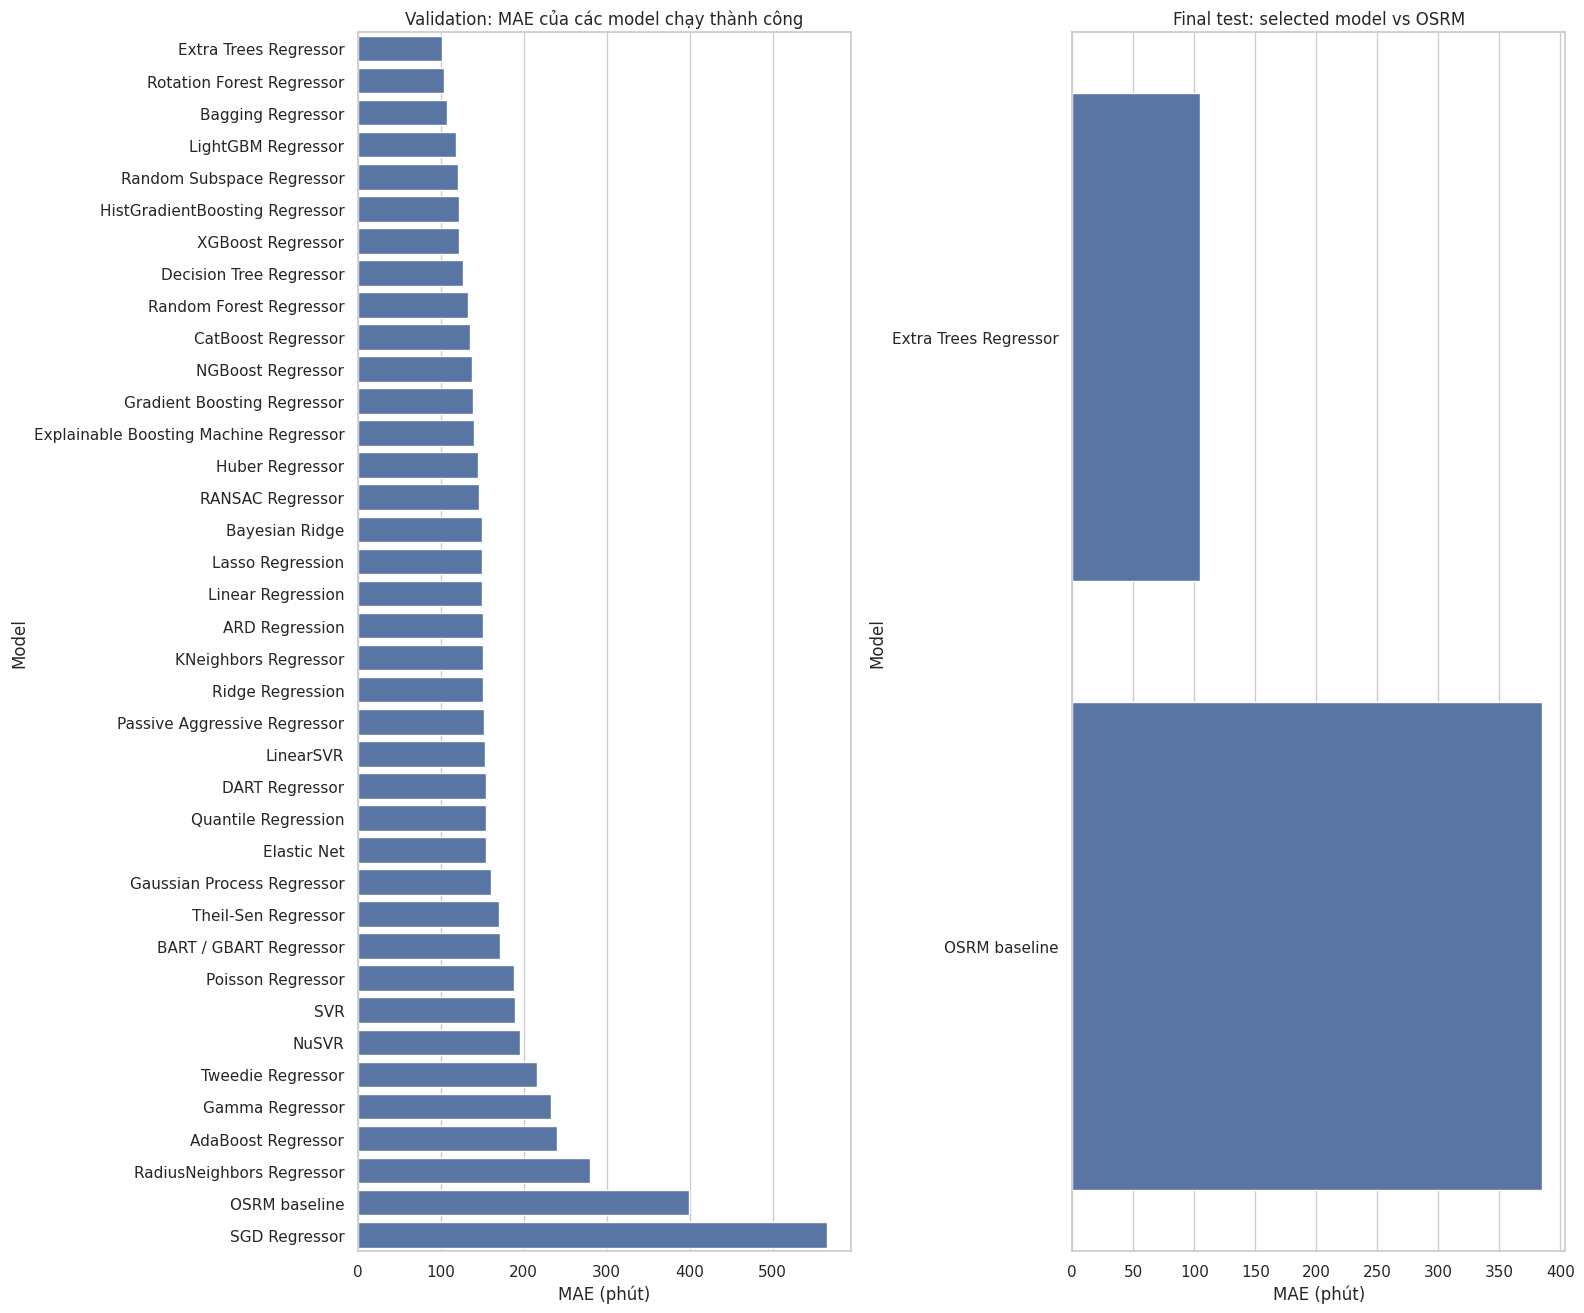

In [26]:
eta_plot_df = eta_validation_results_df.query("Status == 'trained'").copy()

fig, axes = plt.subplots(1, 2, figsize=(16, max(6, 0.35 * len(eta_plot_df))))

sns.barplot(data=eta_plot_df, x='MAE', y='Model', ax=axes[0], color='C0')
axes[0].set_title('Validation: MAE của các model chạy thành công')
axes[0].set_xlabel('MAE (phút)')

sns.barplot(data=eta_test_results_df, x='MAE', y='Model', ax=axes[1], color='C0')
axes[1].set_title('Final test: selected model vs OSRM')
axes[1].set_xlabel('MAE (phút)')

plt.tight_layout()
plt.show()

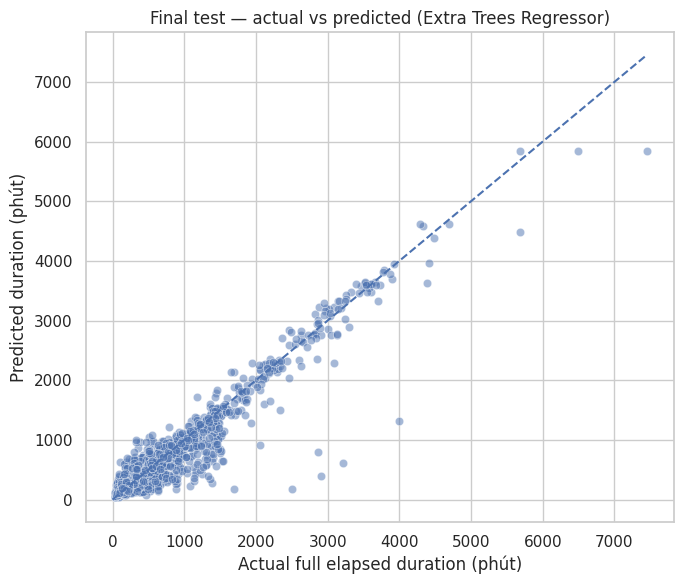

In [27]:
plot_df = pd.DataFrame({
    'Actual': np.asarray(y_test_eta),
    'Predicted': np.asarray(best_eta_pred),
}).sample(min(2500, len(test_df)), random_state=RANDOM_STATE)

plt.figure(figsize=(7, 6))
sns.scatterplot(data=plot_df, x='Actual', y='Predicted', alpha=.5, color='C0')
max_value = max(plot_df['Actual'].max(), plot_df['Predicted'].max())
plt.plot([0, max_value], [0, max_value], linestyle='--')
plt.title(f'Final test — actual vs predicted ({best_eta_model_name})')
plt.xlabel('Actual full elapsed duration (phút)')
plt.ylabel('Predicted duration (phút)')
plt.tight_layout()
plt.show()

## 10. Delay Magnitude Model


Delay magnitude is derived directly from the same ETA/duration prediction:

\[
\widehat{Delay} = \widehat{Duration} - OSRMTime
\]

This keeps the predicted ETA and predicted delay always consistent. It is a **proxy delay relative to the OSRM routing baseline**, not an official SLA delay.


In [28]:
y_test_delay = test_df['delay_minutes']

delay_pred = best_eta_pred - test_df['osrm_time'].to_numpy()

delay_results_df = pd.DataFrame([
    {
        'Model': 'Zero-delay / OSRM baseline',
        **regression_metrics(y_test_delay, np.zeros(len(y_test_delay)))
    },
    {
        'Model': f'Derived from {best_eta_model_name}',
        **regression_metrics(y_test_delay, delay_pred)
    },
]).sort_values('MAE').reset_index(drop=True)

display(delay_results_df)

,Model,MAE,MedianAE,RMSE,R2
0,Derived from Extra Trees Regressor,104.925,53.041,223.811,0.763
1,Zero-delay / OSRM baseline,384.998,208.914,599.942,-0.700


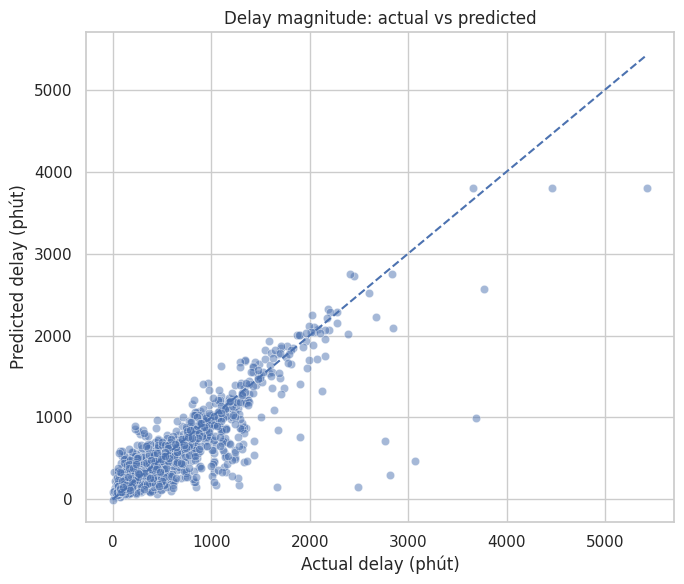

In [29]:
delay_plot = pd.DataFrame({
    'Actual delay': y_test_delay.to_numpy(),
    'Predicted delay': delay_pred,
}).sample(min(2500, len(test_df)), random_state=RANDOM_STATE)

plt.figure(figsize=(7, 6))
sns.scatterplot(data=delay_plot, x='Actual delay', y='Predicted delay', alpha=.5, color='C0')
low = min(delay_plot.min())
high = max(delay_plot.max())
plt.plot([low, high], [low, high], linestyle='--')
plt.title('Delay magnitude: actual vs predicted')
plt.xlabel('Actual delay (phút)')
plt.ylabel('Predicted delay (phút)')
plt.tight_layout()
plt.show()

## 11. Severe-Delay Classification — New Group 4–6 Run, Groups 1–3 Not Rerun


The v5 version already benchmarked 18 classifiers. In v5.1:

- The old metric and threshold snapshot is kept unchanged as static data.
- Decision Tree, Random Forest, Extra Trees, and AdaBoost already have results and are not rerun.
- 14 new classifiers are run: neighbors, bagging/random subspace/rotation forest, imbalanced ensembles, Naive Bayes, LDA/QDA, and Gaussian Process.
- The threshold is optimized separately on the same chronological validation set.
- The old and new leaderboards are merged, and only the overall winning classifier is refit.


In [30]:

old_classifier_validation_results_df = pd.DataFrame(json.loads(r'''[{"Model": "Extra Trees Classifier", "Group": "Existing Trees", "Status": "trained", "Reason": null, "Matrix": "sparse", "FitRows": 8523, "BalancedWeightUsed": true, "TrainingSeconds": 7.076434, "PredictionSeconds": 0.054646, "ProbabilityThreshold": 0.31, "Accuracy": 0.864852, "Precision": 0.893773, "Recall": 0.927757, "F1": 0.910448, "ROC_AUC": 0.923689, "PR_AUC": 0.972613}, {"Model": "LightGBM Classifier", "Group": "1. Gradient Boosting", "Status": "trained", "Reason": null, "Matrix": "sparse", "FitRows": 8523, "BalancedWeightUsed": true, "TrainingSeconds": 0.382113, "PredictionSeconds": 0.017778, "ProbabilityThreshold": 0.29, "Accuracy": 0.852651, "Precision": 0.889163, "Recall": 0.915082, "F1": 0.901936, "ROC_AUC": 0.916039, "PR_AUC": 0.970433}, {"Model": "XGBoost Classifier", "Group": "1. Gradient Boosting", "Status": "trained", "Reason": null, "Matrix": "sparse", "FitRows": 8523, "BalancedWeightUsed": true, "TrainingSeconds": 0.307232, "PredictionSeconds": 0.014493, "ProbabilityThreshold": 0.27, "Accuracy": 0.847959, "Precision": 0.878166, "Recall": 0.922687, "F1": 0.899876, "ROC_AUC": 0.916176, "PR_AUC": 0.970642}, {"Model": "Random Forest Classifier", "Group": "Existing Trees", "Status": "trained", "Reason": null, "Matrix": "sparse", "FitRows": 8523, "BalancedWeightUsed": true, "TrainingSeconds": 1.241651, "PredictionSeconds": 0.076845, "ProbabilityThreshold": 0.3, "Accuracy": 0.841389, "Precision": 0.860465, "Recall": 0.937896, "F1": 0.897514, "ROC_AUC": 0.909789, "PR_AUC": 0.968555}, {"Model": "CatBoost Classifier", "Group": "1. Gradient Boosting", "Status": "trained", "Reason": null, "Matrix": "sparse", "FitRows": 8523, "BalancedWeightUsed": true, "TrainingSeconds": 0.800667, "PredictionSeconds": 0.003848, "ProbabilityThreshold": 0.26, "Accuracy": 0.842797, "Precision": 0.870602, "Recall": 0.925222, "F1": 0.897081, "ROC_AUC": 0.912174, "PR_AUC": 0.969108}, {"Model": "HistGradientBoosting Classifier", "Group": "1. Gradient Boosting", "Status": "trained", "Reason": null, "Matrix": "dense", "FitRows": 8523, "BalancedWeightUsed": true, "TrainingSeconds": 1.436443, "PredictionSeconds": 0.029877, "ProbabilityThreshold": 0.18, "Accuracy": 0.83435, "Precision": 0.84546, "Recall": 0.949937, "F1": 0.894658, "ROC_AUC": 0.906202, "PR_AUC": 0.966753}, {"Model": "Gradient Boosting Classifier", "Group": "1. Gradient Boosting", "Status": "trained", "Reason": null, "Matrix": "dense", "FitRows": 8523, "BalancedWeightUsed": true, "TrainingSeconds": 5.126314, "PredictionSeconds": 0.007452, "ProbabilityThreshold": 0.24, "Accuracy": 0.828719, "Precision": 0.849971, "Recall": 0.93346, "F1": 0.889761, "ROC_AUC": 0.895562, "PR_AUC": 0.961767}, {"Model": "Explainable Boosting Machine Classifier", "Group": "1. Gradient Boosting", "Status": "trained", "Reason": "Explainable Boosting Machine; huấn luyện trên toàn bộ fit.", "Matrix": "dense", "FitRows": 8523, "BalancedWeightUsed": true, "TrainingSeconds": 54.100888, "PredictionSeconds": 0.004246, "ProbabilityThreshold": 0.27, "Accuracy": 0.829657, "Precision": 0.867069, "Recall": 0.909379, "F1": 0.88772, "ROC_AUC": 0.895891, "PR_AUC": 0.963902}, {"Model": "DART Classifier", "Group": "1. Gradient Boosting", "Status": "trained", "Reason": null, "Matrix": "sparse", "FitRows": 8523, "BalancedWeightUsed": true, "TrainingSeconds": 723.892759, "PredictionSeconds": 0.049624, "ProbabilityThreshold": 0.31, "Accuracy": 0.827311, "Precision": 0.862275, "Recall": 0.912548, "F1": 0.8867, "ROC_AUC": 0.889312, "PR_AUC": 0.960771}, {"Model": "SVC", "Group": "2. SVM", "Status": "trained", "Reason": "Kernel SVC với probability=True; huấn luyện trên toàn bộ fit.", "Matrix": "sparse", "FitRows": 8523, "BalancedWeightUsed": true, "TrainingSeconds": 9.625071, "PredictionSeconds": 0.326062, "ProbabilityThreshold": 0.47, "Accuracy": 0.832473, "Precision": 0.890595, "Recall": 0.882129, "F1": 0.886342, "ROC_AUC": 0.889948, "PR_AUC": 0.960904}, {"Model": "Decision Tree Classifier", "Group": "Existing Trees", "Status": "trained", "Reason": null, "Matrix": "sparse", "FitRows": 8523, "BalancedWeightUsed": true, "TrainingSeconds": 0.097645, "PredictionSeconds": 0.000598, "ProbabilityThreshold": 0.13, "Accuracy": 0.820272, "Precision": 0.860157, "Recall": 0.904309, "F1": 0.881681, "ROC_AUC": 0.857925, "PR_AUC": 0.932087}, {"Model": "NuSVC", "Group": "2. SVM", "Status": "trained", "Reason": "Kernel NuSVC với probability=True; huấn luyện trên toàn bộ fit.", "Matrix": "sparse", "FitRows": 8523, "BalancedWeightUsed": true, "TrainingSeconds": 12.785843, "PredictionSeconds": 0.354744, "ProbabilityThreshold": 0.44, "Accuracy": 0.818395, "Precision": 0.855522, "Recall": 0.908112, "F1": 0.881033, "ROC_AUC": 0.883872, "PR_AUC": 0.959084}, {"Model": "NGBoost Classifier", "Group": "1. Gradient Boosting", "Status": "trained", "Reason": "Probabilistic boosting; huấn luyện trên toàn bộ fit.", "Matrix": "dense", "FitRows": 8523, "BalancedWeightUsed": true, "TrainingSeconds": 9.216675, "PredictionSeconds": 0.153694, "ProbabilityThreshold": 0.25, "Accuracy": 0.809948, "Precision": 0.831543, "Recall": 0.932193, "F1": 0.878996, "ROC_AUC": 0.874683, "PR_AUC": 0.955346}, {"Model": "AdaBoost Classifier", "Group": "Existing Trees", "Status": "trained", "Reason": null, "Matrix": "dense", "FitRows": 8523, "BalancedWeightUsed": true, "TrainingSeconds": 3.984819, "PredictionSeconds": 0.065615, "ProbabilityThreshold": 0.31, "Accuracy": 0.797748, "Precision": 0.810504, "Recall": 0.948669, "F1": 0.874161, "ROC_AUC": 0.856108, "PR_AUC": 0.947263}, {"Model": "LinearSVC", "Group": "2. SVM", "Status": "trained", "Reason": null, "Matrix": "sparse", "FitRows": 8523, "BalancedWeightUsed": true, "TrainingSeconds": 0.110316, "PredictionSeconds": 0.001669, "ProbabilityThreshold": 0.25, "Accuracy": 0.794463, "Precision": 0.820946, "Recall": 0.923954, "F1": 0.86941, "ROC_AUC": 0.864784, "PR_AUC": 0.953103}, {"Model": "Logistic Regression", "Group": "3. Linear Models", "Status": "trained", "Reason": null, "Matrix": "sparse", "FitRows": 8523, "BalancedWeightUsed": true, "TrainingSeconds": 0.030781, "PredictionSeconds": 0.000438, "ProbabilityThreshold": 0.26, "Accuracy": 0.794932, "Precision": 0.829578, "Recall": 0.910013, "F1": 0.867936, "ROC_AUC": 0.862792, "PR_AUC": 0.952766}, {"Model": "SGD Classifier", "Group": "3. Linear Models", "Status": "trained", "Reason": null, "Matrix": "sparse", "FitRows": 8523, "BalancedWeightUsed": true, "TrainingSeconds": 0.024759, "PredictionSeconds": 0.000284, "ProbabilityThreshold": 0.21, "Accuracy": 0.787893, "Precision": 0.840799, "Recall": 0.880228, "F1": 0.860062, "ROC_AUC": 0.846308, "PR_AUC": 0.947227}, {"Model": "Passive Aggressive Classifier", "Group": "3. Linear Models", "Status": "trained", "Reason": null, "Matrix": "sparse", "FitRows": 8523, "BalancedWeightUsed": true, "TrainingSeconds": 0.041036, "PredictionSeconds": 0.001545, "ProbabilityThreshold": 0.23, "Accuracy": 0.765368, "Precision": 0.788853, "Recall": 0.932826, "F1": 0.85482, "ROC_AUC": 0.831938, "PR_AUC": 0.942228}]'''))
old_extra_trees_threshold_table = pd.DataFrame(json.loads(r'''[{"Threshold": 0.31, "Accuracy": 0.864852, "Precision": 0.893773, "Recall": 0.927757, "F1": 0.910448, "ROC_AUC": 0.923689, "PR_AUC": 0.972613}, {"Threshold": 0.29, "Accuracy": 0.863444, "Precision": 0.888352, "Recall": 0.932826, "F1": 0.910046, "ROC_AUC": 0.923689, "PR_AUC": 0.972613}, {"Threshold": 0.28, "Accuracy": 0.862506, "Precision": 0.884041, "Recall": 0.937262, "F1": 0.909874, "ROC_AUC": 0.923689, "PR_AUC": 0.972613}, {"Threshold": 0.32, "Accuracy": 0.864383, "Precision": 0.896615, "Recall": 0.923321, "F1": 0.909772, "ROC_AUC": 0.923689, "PR_AUC": 0.972613}, {"Threshold": 0.3, "Accuracy": 0.863444, "Precision": 0.891185, "Recall": 0.929024, "F1": 0.909711, "ROC_AUC": 0.923689, "PR_AUC": 0.972613}, {"Threshold": 0.33, "Accuracy": 0.863914, "Precision": 0.898515, "Recall": 0.920152, "F1": 0.909205, "ROC_AUC": 0.923689, "PR_AUC": 0.972613}, {"Threshold": 0.34, "Accuracy": 0.863444, "Precision": 0.899441, "Recall": 0.918251, "F1": 0.908749, "ROC_AUC": 0.923689, "PR_AUC": 0.972613}, {"Threshold": 0.27, "Accuracy": 0.86016, "Precision": 0.880499, "Recall": 0.93853, "F1": 0.908589, "ROC_AUC": 0.923689, "PR_AUC": 0.972613}, {"Threshold": 0.36, "Accuracy": 0.862975, "Precision": 0.901875, "Recall": 0.914449, "F1": 0.908118, "ROC_AUC": 0.923689, "PR_AUC": 0.972613}, {"Threshold": 0.35, "Accuracy": 0.862506, "Precision": 0.900312, "Recall": 0.915716, "F1": 0.907948, "ROC_AUC": 0.923689, "PR_AUC": 0.972613}]'''))
old_classification_test_results_df = pd.DataFrame(json.loads(r'''[{"Model": "Extra Trees Classifier", "Probability threshold": 0.31, "Balanced weight used": true, "Accuracy": 0.854912, "Precision": 0.8777, "Recall": 0.926559, "F1": 0.901468, "ROC_AUC": 0.9132, "PR_AUC": 0.964784}]'''))

display(old_classifier_validation_results_df.style.set_caption(
    'Snapshot v5 — 18 classifier cũ (không chạy lại)'
))
print('Old selected classifier from v5 validation: Extra Trees Classifier')
print('Old selected probability threshold: 0.31')
display(old_extra_trees_threshold_table.style.set_caption('Snapshot v5 — top thresholds'))
display(old_classification_test_results_df.style.set_caption('Snapshot v5 — final test cũ'))


,Model,Group,Status,Reason,Matrix,FitRows,BalancedWeightUsed,TrainingSeconds,PredictionSeconds,ProbabilityThreshold,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Extra Trees Classifier,Existing Trees,trained,None,sparse,8523,True,7.076434,0.054646,0.310000,0.864852,0.893773,0.927757,0.910448,0.923689,0.972613
1,LightGBM Classifier,1. Gradient Boosting,trained,None,sparse,8523,True,0.382113,0.017778,0.290000,0.852651,0.889163,0.915082,0.901936,0.916039,0.970433
2,XGBoost Classifier,1. Gradient Boosting,trained,None,sparse,8523,True,0.307232,0.014493,0.270000,0.847959,0.878166,0.922687,0.899876,0.916176,0.970642
3,Random Forest Classifier,Existing Trees,trained,None,sparse,8523,True,1.241651,0.076845,0.300000,0.841389,0.860465,0.937896,0.897514,0.909789,0.968555
4,CatBoost Classifier,1. Gradient Boosting,trained,None,sparse,8523,True,0.800667,0.003848,0.260000,0.842797,0.870602,0.925222,0.897081,0.912174,0.969108
5,HistGradientBoosting Classifier,1. Gradient Boosting,trained,None,dense,8523,True,1.436443,0.029877,0.180000,0.834350,0.845460,0.949937,0.894658,0.906202,0.966753
6,Gradient Boosting Classifier,1. Gradient Boosting,trained,None,dense,8523,True,5.126314,0.007452,0.240000,0.828719,0.849971,0.933460,0.889761,0.895562,0.961767
7,Explainable Boosting Machine Classifier,1. Gradient Boosting,trained,Explainable Boosting Machine; huấn luyện trên toàn bộ fit.,dense,8523,True,54.100888,0.004246,0.270000,0.829657,0.867069,0.909379,0.887720,0.895891,0.963902
8,DART Classifier,1. Gradient Boosting,trained,None,sparse,8523,True,723.892759,0.049624,0.310000,0.827311,0.862275,0.912548,0.886700,0.889312,0.960771
9,SVC,2. SVM,trained,Kernel SVC với probability=True; huấn luyện trên toàn bộ fit.,sparse,8523,True,9.625071,0.326062,0.470000,0.832473,0.890595,0.882129,0.886342,0.889948,0.960904


Old selected classifier from v5 validation: Extra Trees Classifier
Old selected probability threshold: 0.31


,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,0.310000,0.864852,0.893773,0.927757,0.910448,0.923689,0.972613
1,0.290000,0.863444,0.888352,0.932826,0.910046,0.923689,0.972613
2,0.280000,0.862506,0.884041,0.937262,0.909874,0.923689,0.972613
3,0.320000,0.864383,0.896615,0.923321,0.909772,0.923689,0.972613
4,0.300000,0.863444,0.891185,0.929024,0.909711,0.923689,0.972613
5,0.330000,0.863914,0.898515,0.920152,0.909205,0.923689,0.972613
6,0.340000,0.863444,0.899441,0.918251,0.908749,0.923689,0.972613
7,0.270000,0.860160,0.880499,0.938530,0.908589,0.923689,0.972613
8,0.360000,0.862975,0.901875,0.914449,0.908118,0.923689,0.972613
9,0.350000,0.862506,0.900312,0.915716,0.907948,0.923689,0.972613


,Model,Probability threshold,Balanced weight used,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Extra Trees Classifier,0.310000,True,0.854912,0.877700,0.926559,0.901468,0.913200,0.964784


In [31]:
def classification_metrics_at_threshold(y_true, probability, threshold):
    pred = (np.asarray(probability) >= threshold).astype(int)
    return {
        'Accuracy': accuracy_score(y_true, pred),
        'Precision': precision_score(y_true, pred, zero_division=0),
        'Recall': recall_score(y_true, pred, zero_division=0),
        'F1': f1_score(y_true, pred, zero_division=0),
        'ROC_AUC': safe_roc_auc(y_true, probability),
        'PR_AUC': average_precision_score(y_true, probability),
    }


def optimize_probability_threshold(y_true, probability):
    rows=[]
    for threshold in np.linspace(0.05, 0.95, 91):
        rows.append({'Threshold': threshold,
                     **classification_metrics_at_threshold(y_true, probability, threshold)})
    table=pd.DataFrame(rows)
    best=table.sort_values(['F1','Recall','Precision'], ascending=False).iloc[0]
    return float(best['Threshold']), table


def benchmark_classifiers(specs, X_fit_base, y_fit, X_validation_base, y_validation):
    rows, probabilities, threshold_tables = [], {}, {}
    for position, spec in enumerate(specs, start=1):
        available, dependency_message = optional_dependency_available(spec.optional_dependency)
        if spec.optional_dependency and not available:
            rows.append({
                'Model': spec.name, 'Group': spec.group, 'Status': 'skipped',
                'Reason': dependency_message, 'Matrix': spec.matrix_kind, 'FitRows': 0,
                'BalancedWeightUsed': False, 'TrainingSeconds': np.nan,
                'PredictionSeconds': np.nan, 'ProbabilityThreshold': np.nan,
                'Accuracy': np.nan, 'Precision': np.nan, 'Recall': np.nan,
                'F1': np.nan, 'ROC_AUC': np.nan, 'PR_AUC': np.nan,
            })
            print(f'[{position:02d}/{len(specs)}] SKIP {spec.name}: {dependency_message}')
            continue
        try:
            X_fit_model = prepare_model_matrix(X_fit_base, spec.matrix_kind)
            X_validation_model = prepare_model_matrix(X_validation_base, spec.matrix_kind)
            model=spec.factory()
            start=time.perf_counter()
            model, balanced_used = fit_classifier_with_balancing(model, X_fit_model, y_fit)
            training_seconds=time.perf_counter()-start
            start=time.perf_counter()
            probability=positive_class_probability(model, X_validation_model)
            prediction_seconds=time.perf_counter()-start
            threshold, threshold_table=optimize_probability_threshold(y_validation, probability)
            metrics=classification_metrics_at_threshold(y_validation, probability, threshold)
            probabilities[spec.name]=probability
            threshold_tables[spec.name]=threshold_table
            rows.append({
                'Model': spec.name, 'Group': spec.group, 'Status': 'trained',
                'Reason': spec.note, 'Matrix': spec.matrix_kind, 'FitRows': len(y_fit),
                'BalancedWeightUsed': balanced_used, 'TrainingSeconds': training_seconds,
                'PredictionSeconds': prediction_seconds, 'ProbabilityThreshold': threshold,
                **metrics,
            })
            print(f'[{position:02d}/{len(specs)}] OK   {spec.name}: '
                  f'F1={metrics["F1"]:.3f}; ROC-AUC={metrics["ROC_AUC"]:.3f}; '
                  f'threshold={threshold:.2f}; fit={training_seconds:.2f}s; rows={len(y_fit):,}')
        except Exception as exc:
            rows.append({
                'Model': spec.name, 'Group': spec.group, 'Status': 'failed',
                'Reason': f'{type(exc).__name__}: {exc}', 'Matrix': spec.matrix_kind,
                'FitRows': 0, 'BalancedWeightUsed': False, 'TrainingSeconds': np.nan,
                'PredictionSeconds': np.nan, 'ProbabilityThreshold': np.nan,
                'Accuracy': np.nan, 'Precision': np.nan, 'Recall': np.nan,
                'F1': np.nan, 'ROC_AUC': np.nan, 'PR_AUC': np.nan,
            })
            print(f'[{position:02d}/{len(specs)}] FAIL {spec.name}: {type(exc).__name__}: {exc}')
        finally:
            gc.collect()
    return pd.DataFrame(rows), probabilities, threshold_tables


y_fit_cls=(fit_df['delay_minutes'] > DELAY_THRESHOLD_MINUTES).astype(int).to_numpy()
y_validation_cls=(validation_df['delay_minutes'] > DELAY_THRESHOLD_MINUTES).astype(int).to_numpy()

(new_classifier_validation_results_df,
 new_classifier_validation_probabilities,
 new_classifier_threshold_tables) = benchmark_classifiers(
    NEW_CLASSIFICATION_SPECS, X_fit_t, y_fit_cls, X_validation_t, y_validation_cls
)

display(new_classifier_validation_results_df.sort_values(
    ['F1','ROC_AUC'], ascending=False
).style.set_caption('v5.1 — chỉ classifier mới thuộc Nhóm 4–6'))

classifier_validation_results_df = pd.concat(
    [old_classifier_validation_results_df, new_classifier_validation_results_df],
    ignore_index=True,
).sort_values(['Status','F1','ROC_AUC','Recall'],
              ascending=[True,False,False,False], na_position='last').reset_index(drop=True)

display(classifier_validation_results_df.style.set_caption(
    'Combined classifier leaderboard — snapshot v5 + model mới v5.1'
))

classifier_candidates_df=classifier_validation_results_df.query("Status == 'trained'").copy()
best_classifier_row=classifier_candidates_df.sort_values(
    ['F1','ROC_AUC','Recall','Precision'], ascending=False
).iloc[0]
best_classifier_name=best_classifier_row['Model']
best_classification_threshold=float(best_classifier_row['ProbabilityThreshold'])
combined_classifier_spec_lookup={spec.name: spec for spec in CLASSIFICATION_SPECS}
best_classifier_spec=combined_classifier_spec_lookup[best_classifier_name]
print(f'Selected classifier from combined validation: {best_classifier_name}')
print(f'Selected classification threshold: {best_classification_threshold:.2f}')

if best_classifier_name in new_classifier_threshold_tables:
    display(new_classifier_threshold_tables[best_classifier_name].sort_values(
        ['F1','Recall','Precision'], ascending=False
    ).head(10).style.set_caption(f'Top thresholds — {best_classifier_name}'))
elif best_classifier_name == 'Extra Trees Classifier':
    display(old_extra_trees_threshold_table.style.set_caption(
        'Top thresholds — Extra Trees Classifier (snapshot v5)'
    ))

y_train_cls=(train_df['delay_minutes'] > DELAY_THRESHOLD_MINUTES).astype(int).to_numpy()
y_test_cls=(test_df['delay_minutes'] > DELAY_THRESHOLD_MINUTES).astype(int).to_numpy()
classifier_matrix_kind=best_classifier_spec.matrix_kind
X_train_classifier=prepare_model_matrix(X_train_t, classifier_matrix_kind)
X_test_classifier=prepare_model_matrix(X_test_t, classifier_matrix_kind)
classifier=best_classifier_spec.factory()
classifier, final_balanced_weight_used=fit_classifier_with_balancing(
    classifier, X_train_classifier, y_train_cls
)
severe_delay_probability=positive_class_probability(classifier, X_test_classifier)
severe_delay_pred=(severe_delay_probability >= best_classification_threshold).astype(int)
classification_metrics=pd.DataFrame([{
    'Model': best_classifier_name,
    'Probability threshold': best_classification_threshold,
    'Balanced weight used': final_balanced_weight_used,
    **classification_metrics_at_threshold(
        y_test_cls, severe_delay_probability, best_classification_threshold
    ),
}])

display(classification_metrics.style.set_caption('Final test — combined selected classifier'))
print(f'Train positive rate: {y_train_cls.mean():.2%}')
print(f'Test positive rate: {y_test_cls.mean():.2%}')
print(classification_report(y_test_cls, severe_delay_pred, digits=3, zero_division=0))


[01/14] OK   KNeighbors Classifier: F1=0.875; ROC-AUC=0.853; threshold=0.44; fit=0.01s; rows=8,523
[02/14] OK   RadiusNeighbors Classifier: F1=0.852; ROC-AUC=0.782; threshold=0.56; fit=0.01s; rows=8,523
[03/14] OK   Bagging Classifier: F1=0.905; ROC-AUC=0.919; threshold=0.32; fit=10.99s; rows=8,523
[04/14] OK   Random Subspace Classifier: F1=0.903; ROC-AUC=0.914; threshold=0.40; fit=8.03s; rows=8,523
[05/14] OK   Rotation Forest Classifier: F1=0.905; ROC-AUC=0.915; threshold=0.47; fit=63.29s; rows=8,523
[06/14] OK   Balanced Random Forest Classifier: F1=0.902; ROC-AUC=0.920; threshold=0.26; fit=3.55s; rows=8,523
[07/14] OK   Easy Ensemble Classifier: F1=0.873; ROC-AUC=0.853; threshold=0.24; fit=7.70s; rows=8,523
[08/14] OK   RUSBoost Classifier: F1=0.851; ROC-AUC=0.833; threshold=0.05; fit=0.95s; rows=8,523
[09/14] OK   Gaussian Naive Bayes: F1=0.303; ROC-AUC=0.777; threshold=0.05; fit=0.02s; rows=8,523
[10/14] OK   Bernoulli Naive Bayes: F1=0.803; ROC-AUC=0.767; threshold=0.05; fit=0.

,Model,Group,Status,Reason,Matrix,FitRows,BalancedWeightUsed,TrainingSeconds,PredictionSeconds,ProbabilityThreshold,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
4,Rotation Forest Classifier,5. Bagging & Randomized Ensemble,trained,,dense,8523,True,63.294974,0.645538,0.470000,0.857813,0.895226,0.915082,0.905045,0.914517,0.966750
2,Bagging Classifier,5. Bagging & Randomized Ensemble,trained,,sparse,8523,True,10.987749,0.133761,0.320000,0.852182,0.863977,0.949937,0.904920,0.918780,0.970204
3,Random Subspace Classifier,5. Bagging & Randomized Ensemble,trained,,sparse,8523,True,8.029432,0.170164,0.400000,0.852182,0.882033,0.923954,0.902507,0.914208,0.969454
5,Balanced Random Forest Classifier,5. Bagging & Randomized Ensemble,trained,,sparse,8523,True,3.551453,0.076598,0.260000,0.852182,0.889574,0.913815,0.901532,0.919922,0.972312
13,Gaussian Process Classifier,6. Probabilistic & Statistical Models,trained,Exact Gaussian Process trên toàn bộ fit; có thể cần RAM/thời gian rất lớn.,dense,8523,False,168.955023,7.138247,0.460000,0.814641,0.828064,0.946134,0.883171,0.868605,0.948892
0,KNeighbors Classifier,4. Nearest Neighbors,trained,,sparse,8523,False,0.005597,0.858445,0.440000,0.803848,0.830296,0.923954,0.874625,0.853004,0.946548
6,Easy Ensemble Classifier,5. Bagging & Randomized Ensemble,trained,,sparse,8523,False,7.704529,0.763594,0.240000,0.793524,0.800740,0.960076,0.873199,0.853327,0.940428
1,RadiusNeighbors Classifier,4. Nearest Neighbors,trained,,sparse,8523,True,0.005019,2.194067,0.560000,0.742844,0.742467,0.999366,0.851972,0.782233,0.920485
11,Linear Discriminant Analysis (LDA),6. Probabilistic & Statistical Models,trained,,dense,8523,False,0.086473,0.001298,0.280000,0.741905,0.741769,0.999366,0.851512,0.781709,0.920289
7,RUSBoost Classifier,5. Bagging & Randomized Ensemble,trained,,sparse,8523,True,0.950099,0.030023,0.050000,0.740497,0.740497,1.000000,0.850903,0.833360,0.926730


,Model,Group,Status,Reason,Matrix,FitRows,BalancedWeightUsed,TrainingSeconds,PredictionSeconds,ProbabilityThreshold,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Extra Trees Classifier,Existing Trees,trained,None,sparse,8523,True,7.076434,0.054646,0.310000,0.864852,0.893773,0.927757,0.910448,0.923689,0.972613
1,Rotation Forest Classifier,5. Bagging & Randomized Ensemble,trained,,dense,8523,True,63.294974,0.645538,0.470000,0.857813,0.895226,0.915082,0.905045,0.914517,0.966750
2,Bagging Classifier,5. Bagging & Randomized Ensemble,trained,,sparse,8523,True,10.987749,0.133761,0.320000,0.852182,0.863977,0.949937,0.904920,0.918780,0.970204
3,Random Subspace Classifier,5. Bagging & Randomized Ensemble,trained,,sparse,8523,True,8.029432,0.170164,0.400000,0.852182,0.882033,0.923954,0.902507,0.914208,0.969454
4,LightGBM Classifier,1. Gradient Boosting,trained,None,sparse,8523,True,0.382113,0.017778,0.290000,0.852651,0.889163,0.915082,0.901936,0.916039,0.970433
5,Balanced Random Forest Classifier,5. Bagging & Randomized Ensemble,trained,,sparse,8523,True,3.551453,0.076598,0.260000,0.852182,0.889574,0.913815,0.901532,0.919922,0.972312
6,XGBoost Classifier,1. Gradient Boosting,trained,None,sparse,8523,True,0.307232,0.014493,0.270000,0.847959,0.878166,0.922687,0.899876,0.916176,0.970642
7,Random Forest Classifier,Existing Trees,trained,None,sparse,8523,True,1.241651,0.076845,0.300000,0.841389,0.860465,0.937896,0.897514,0.909789,0.968555
8,CatBoost Classifier,1. Gradient Boosting,trained,None,sparse,8523,True,0.800667,0.003848,0.260000,0.842797,0.870602,0.925222,0.897081,0.912174,0.969108
9,HistGradientBoosting Classifier,1. Gradient Boosting,trained,None,dense,8523,True,1.436443,0.029877,0.180000,0.834350,0.845460,0.949937,0.894658,0.906202,0.966753


Selected classifier from combined validation: Extra Trees Classifier
Selected classification threshold: 0.31


,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,0.310000,0.864852,0.893773,0.927757,0.910448,0.923689,0.972613
1,0.290000,0.863444,0.888352,0.932826,0.910046,0.923689,0.972613
2,0.280000,0.862506,0.884041,0.937262,0.909874,0.923689,0.972613
3,0.320000,0.864383,0.896615,0.923321,0.909772,0.923689,0.972613
4,0.300000,0.863444,0.891185,0.929024,0.909711,0.923689,0.972613
5,0.330000,0.863914,0.898515,0.920152,0.909205,0.923689,0.972613
6,0.340000,0.863444,0.899441,0.918251,0.908749,0.923689,0.972613
7,0.270000,0.860160,0.880499,0.938530,0.908589,0.923689,0.972613
8,0.360000,0.862975,0.901875,0.914449,0.908118,0.923689,0.972613
9,0.350000,0.862506,0.900312,0.915716,0.907948,0.923689,0.972613


,Model,Probability threshold,Balanced weight used,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Extra Trees Classifier,0.310000,True,0.854912,0.877700,0.926559,0.901468,0.913200,0.964784


Train positive rate: 72.66%
Test positive rate: 71.63%
              precision    recall  f1-score   support

           0      0.784     0.674     0.725      1181
           1      0.878     0.927     0.901      2982

    accuracy                          0.855      4163
   macro avg      0.831     0.800     0.813      4163
weighted avg      0.851     0.855     0.851      4163



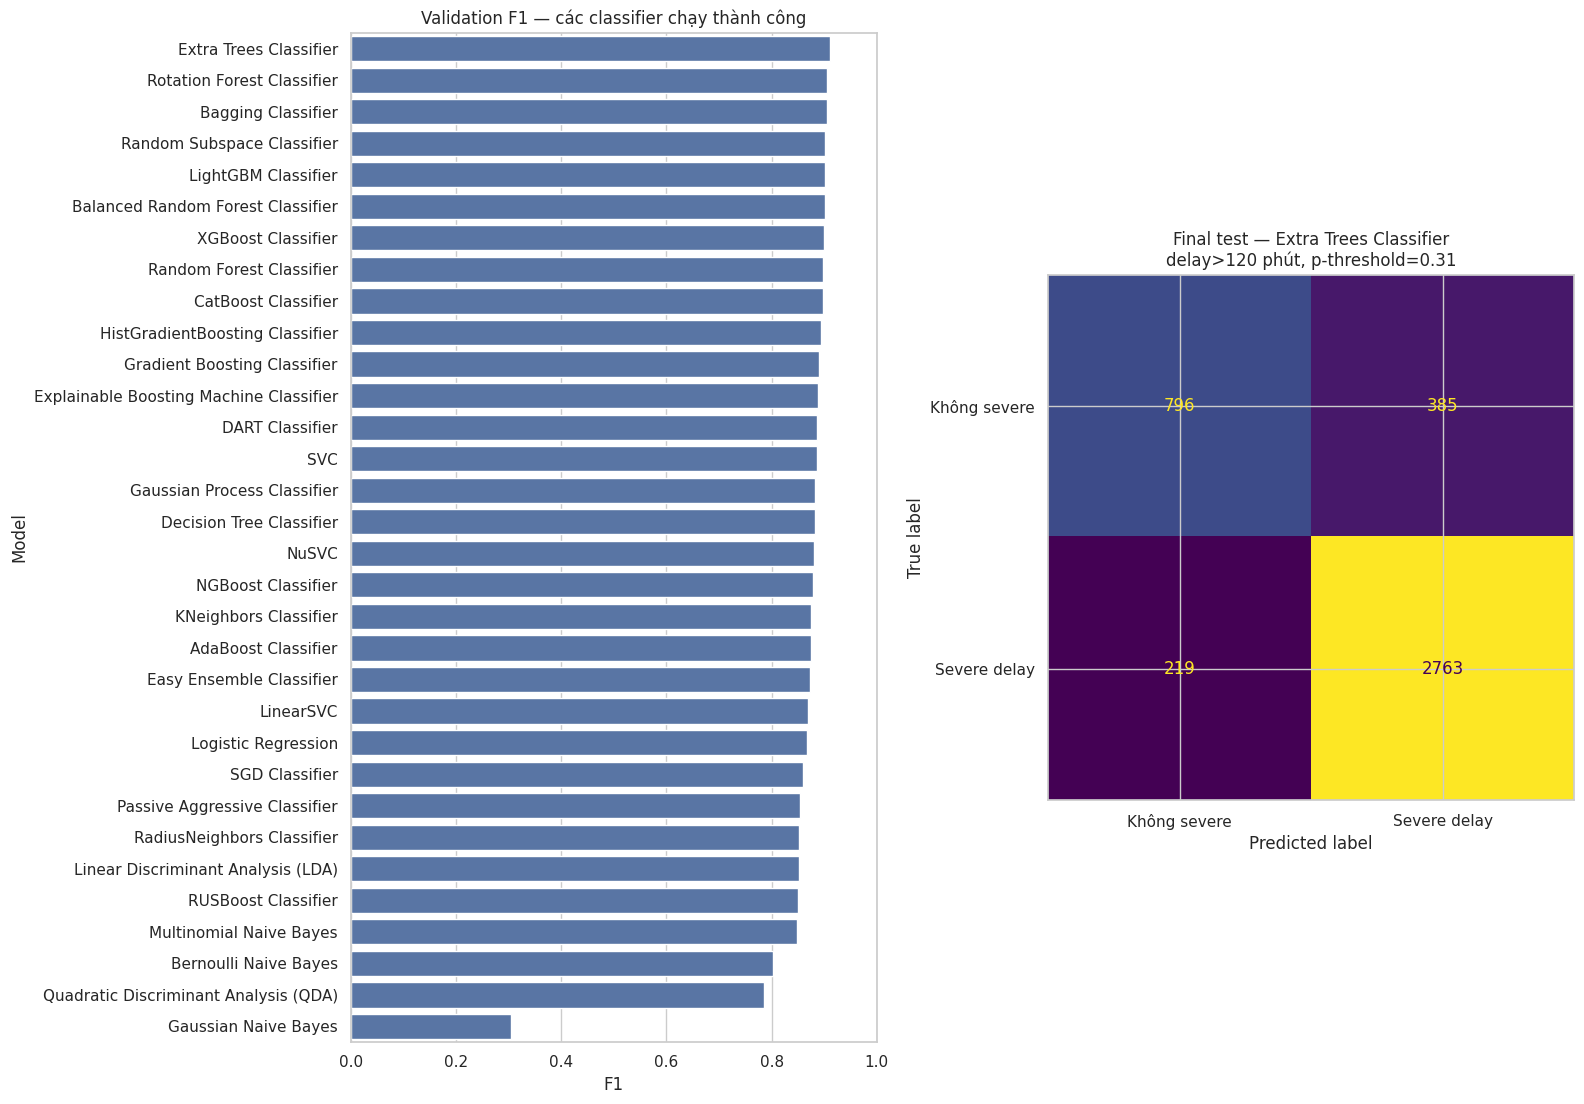

In [32]:
classifier_plot_df = classifier_validation_results_df.query(
    "Status == 'trained'"
).sort_values('F1', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, max(6, 0.35 * len(classifier_plot_df))))

sns.barplot(
    data=classifier_plot_df,
    x='F1',
    y='Model',
    ax=axes[0],
    color='C0',
)
axes[0].set_title('Validation F1 — các classifier chạy thành công')
axes[0].set_xlim(0, 1)

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test_cls, severe_delay_pred),
    display_labels=['Không severe', 'Severe delay']
).plot(ax=axes[1], values_format='d', colorbar=False)
axes[1].set_title(
    f'Final test — {best_classifier_name}\n'
    f'delay>{DELAY_THRESHOLD_MINUTES} phút, p-threshold={best_classification_threshold:.2f}'
)

plt.tight_layout()
plt.show()

## 12. Delay Propagation — Benchmark with the Same 37 ETA Regressors


The start-of-trip model uses only planned information. To represent delay propagation, the notebook creates a snapshot after each observed checkpoint.

At checkpoint \(k\):

\[
StageDelay_k = SegmentActualTime_k - SegmentOSRMTime_k
\]

\[
CumulativeDelay_k = \sum_{i=1}^{k} StageDelay_i
\]

Checkpoints are sorted by `cutoff_timestamp`. `total_stages` is excluded because it is future information. Progress is normalized by the route's total planned segment time, assuming the segment plan is available in advance.

### Propagation Model Selection Procedure

1. Build `stage_fit` from trips in `fit_df` and `stage_validation` from trips in `validation_df`.
2. Use **the entire `REGRESSION_SPECS`, identical to the ETA task**: 31 old models + 6 Group 4–6 models = 37 regressors.
3. Each model is trained on the full `stage_fit`, with no sample limit.
4. Each trip has an equal total sample weight so that trips with more checkpoints do not dominate the result.
5. On validation, each trip contributes only one checkpoint closest to 25%, 50%, 75%, and 100% progress.
6. The model is selected by the lowest `MeanCheckpointMAE`; ties are broken by weighted MAE, weighted RMSE, and R².
7. The winning model is refit on the full `stage_train`, then evaluated on the final `stage_test`.

GLMs that require a positive target (`Poisson`, `Gamma`, `Tweedie`) are wrapped with a target shift during fitting and an inverse shift at prediction time, because `final_delay_minutes` can be negative.


In [33]:
stage_df = df.query('segment_actual_time >= 0 and segment_osrm_time > 0').copy()
stage_df = stage_df.sort_values(
    ['trip_uuid', 'od_start_time', 'cutoff_timestamp', '_row_order'],
    na_position='last',
).reset_index(drop=True)

trip_targets = trip_df[[
    'trip_uuid', 'trip_duration_minutes', 'osrm_time', 'osrm_distance', 'delay_minutes'
]].rename(columns={
    'trip_duration_minutes': 'final_trip_duration',
    'osrm_time': 'trip_osrm_time',
    'osrm_distance': 'trip_osrm_distance',
    'delay_minutes': 'final_delay_minutes',
})

stage_df = stage_df.merge(trip_targets, on='trip_uuid', how='inner')
stage_group = stage_df.groupby('trip_uuid', sort=False)

stage_df['stage_index'] = stage_group.cumcount() + 1
stage_df['total_segment_osrm_time'] = stage_group['segment_osrm_time'].transform('sum')
stage_df['cum_actual_time'] = stage_group['segment_actual_time'].cumsum()
stage_df['cum_osrm_time'] = stage_group['segment_osrm_time'].cumsum()
stage_df['current_stage_delay'] = stage_df['segment_actual_time'] - stage_df['segment_osrm_time']
stage_df['cum_stage_delay'] = stage_df['cum_actual_time'] - stage_df['cum_osrm_time']
stage_df['previous_stage_delay'] = stage_group['current_stage_delay'].shift(1).fillna(0)
stage_df['progress_ratio'] = (
    stage_df['cum_osrm_time'] /
    stage_df['total_segment_osrm_time'].replace(0, np.nan)
).clip(0, 1)
stage_df['remaining_segment_plan_time'] = (
    stage_df['total_segment_osrm_time'] - stage_df['cum_osrm_time']
).clip(lower=0)
stage_df['start_hour'] = stage_df['od_start_time'].dt.hour
stage_df['start_dayofweek'] = stage_df['od_start_time'].dt.dayofweek

STAGE_NUMERIC_FEATURES = [
    'segment_actual_time', 'segment_osrm_time', 'segment_osrm_distance',
    'current_stage_delay', 'previous_stage_delay',
    'cum_actual_time', 'cum_osrm_time', 'cum_stage_delay',
    'progress_ratio', 'remaining_segment_plan_time',
    'stage_index',
    'trip_osrm_time', 'trip_osrm_distance',
    'start_hour', 'start_dayofweek',
]
STAGE_CATEGORICAL_FEATURES = ['route_type', 'source_state', 'destination_state']
STAGE_FEATURES = STAGE_NUMERIC_FEATURES + STAGE_CATEGORICAL_FEATURES

assert 'total_stages' not in STAGE_FEATURES
assert stage_df['progress_ratio'].between(0, 1).all()

print(f'Stage-level shape after quality filters: {stage_df.shape}')
print(f'Unique stage trips: {stage_df.trip_uuid.nunique():,}')
print(f'Rows excluded by stage quality rules: {len(df) - len(stage_df):,}')
display(stage_df[STAGE_FEATURES + ['final_delay_minutes']].head())

Stage-level shape after quality filters: (142502, 46)
Unique stage trips: 14,817
Rows excluded by stage quality rules: 2,365


,segment_actual_time,segment_osrm_time,segment_osrm_distance,current_stage_delay,previous_stage_delay,cum_actual_time,cum_osrm_time,cum_stage_delay,progress_ratio,remaining_segment_plan_time,stage_index,trip_osrm_time,trip_osrm_distance,start_hour,start_dayofweek,route_type,source_state,destination_state,final_delay_minutes
0,22.000,3.000,5.390,19.000,0.000,22.000,3.000,19.000,0.003,"1,005.000",1,743.000,991.352,0,2,FTL,Madhya Pradesh,Uttar Pradesh,"1,517.110"
1,31.000,21.000,25.184,10.000,19.000,53.000,24.000,29.000,0.024,984.000,2,743.000,991.352,0,2,FTL,Madhya Pradesh,Uttar Pradesh,"1,517.110"
2,46.000,25.000,32.615,21.000,10.000,99.000,49.000,50.000,0.049,959.000,3,743.000,991.352,0,2,FTL,Madhya Pradesh,Uttar Pradesh,"1,517.110"
3,30.000,18.000,26.442,12.000,21.000,129.000,67.000,62.000,0.066,941.000,4,743.000,991.352,0,2,FTL,Madhya Pradesh,Uttar Pradesh,"1,517.110"
4,33.000,20.000,28.703,13.000,12.000,162.000,87.000,75.000,0.086,921.000,5,743.000,991.352,0,2,FTL,Madhya Pradesh,Uttar Pradesh,"1,517.110"


In [ ]:
def make_stage_preprocessor():
    return ColumnTransformer(
        transformers=[
            ('numeric', Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
            ]), STAGE_NUMERIC_FEATURES),
            ('categorical', Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(
                    handle_unknown='ignore',
                    min_frequency=20,
                    sparse_output=True,
                )),
            ]), STAGE_CATEGORICAL_FEATURES),
        ],
        remainder='drop',
    )


def select_one_checkpoint_per_trip(frame, target_progress):
    """Chọn checkpoint gần target progress nhất; mỗi trip đúng một dòng."""
    distance = (frame['progress_ratio'] - target_progress).abs()
    selected_index = distance.groupby(frame['trip_uuid']).idxmin()
    return selected_index


def make_equal_trip_weights(frame):
    """Mỗi trip có tổng weight bằng nhau, bất kể số checkpoint."""
    count_per_trip = frame.groupby('trip_uuid')['trip_uuid'].transform('size')
    weights = 1.0 / count_per_trip.to_numpy(dtype=float)
    return weights / weights.mean()


class ShiftedPositiveTargetRegressor(BaseEstimator, RegressorMixin):
    """Dịch target sang miền dương cho Poisson/Gamma/Tweedie rồi dịch ngược dự đoán."""
    def __init__(self, estimator, epsilon=1e-6):
        self.estimator = estimator
        self.epsilon = epsilon

    def fit(self, X, y, sample_weight=None):
        y = np.asarray(y, dtype=float)
        self.target_shift_ = max(self.epsilon - float(np.nanmin(y)), 0.0)
        shifted_y = y + self.target_shift_
        self.estimator_ = self.estimator
        if sample_weight is not None:
            try:
                self.estimator_.fit(X, shifted_y, sample_weight=sample_weight)
            except (TypeError, ValueError):
                self.estimator_.fit(X, shifted_y)
        else:
            self.estimator_.fit(X, shifted_y)
        if hasattr(self.estimator_, 'n_features_in_'):
            self.n_features_in_ = self.estimator_.n_features_in_
        return self

    def predict(self, X):
        return np.asarray(self.estimator_.predict(X), dtype=float) - self.target_shift_


def make_propagation_estimator(spec):
    """Dùng cùng model factory ETA; chỉ bọc GLM có ràng buộc target dương."""
    estimator = spec.factory()
    if spec.name in {'Poisson Regressor', 'Gamma Regressor', 'Tweedie Regressor'}:
        estimator = ShiftedPositiveTargetRegressor(estimator)
    return estimator


def fit_regressor_with_trip_weights(model, X, y, sample_weight):
    """Dùng equal-trip sample weight khi model hỗ trợ; fallback không weight nếu API không hỗ trợ."""
    try:
        model.fit(X, y, sample_weight=sample_weight)
        return model, True
    except (TypeError, ValueError):
        model.fit(X, y)
        return model, False


def propagation_regression_metrics(y_true, y_pred, sample_weight=None):
    """Metric cho delay có thể âm; không clip prediction về 0 như ETA duration."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        'MAE': mean_absolute_error(y_true, y_pred, sample_weight=sample_weight),
        'MedianAE': median_absolute_error(y_true, y_pred, sample_weight=sample_weight),
        'RMSE': root_mean_squared_error(y_true, y_pred, sample_weight=sample_weight),
        'R2': r2_score(y_true, y_pred, sample_weight=sample_weight),
    }


def propagation_checkpoint_metrics(frame, prediction):
    """Chấm một model tại 25/50/75/100%; mỗi trip một quan sát ở mỗi mốc."""
    prediction = pd.Series(np.asarray(prediction), index=frame.index)
    rows = []
    for target_progress, label in [
        (0.25, '25%'),
        (0.50, '50%'),
        (0.75, '75%'),
        (1.00, '100%'),
    ]:
        selected_index = select_one_checkpoint_per_trip(frame, target_progress)
        selected = frame.loc[selected_index]
        selected_pred = prediction.loc[selected_index].to_numpy()
        rows.append({
            'Checkpoint': label,
            'Trips': selected['trip_uuid'].nunique(),
            'Mean actual progress': selected['progress_ratio'].mean(),
            **propagation_regression_metrics(
                selected['final_delay_minutes'], selected_pred
            ),
        })
    return pd.DataFrame(rows)


def benchmark_propagation_regressors(
    specs,
    X_fit_base,
    y_fit,
    fit_weights,
    X_validation_base,
    validation_frame,
    validation_weights,
):
    rows = []
    checkpoint_tables = {}

    for position, spec in enumerate(specs, start=1):
        available, dependency_message = optional_dependency_available(
            spec.optional_dependency
        )
        if spec.optional_dependency and not available:
            rows.append({
                'Model': spec.name,
                'Group': spec.group,
                'Status': 'skipped',
                'Reason': dependency_message,
                'Matrix': spec.matrix_kind,
                'FitRows': 0,
                'TripWeightUsed': False,
                'TrainingSeconds': np.nan,
                'PredictionSeconds': np.nan,
                'MeanCheckpointMAE': np.nan,
                'Checkpoint25_MAE': np.nan,
                'Checkpoint50_MAE': np.nan,
                'Checkpoint75_MAE': np.nan,
                'Checkpoint100_MAE': np.nan,
                'WeightedMAE': np.nan,
                'WeightedMedianAE': np.nan,
                'WeightedRMSE': np.nan,
                'WeightedR2': np.nan,
            })
            print(
                f'[{position:02d}/{len(specs)}] SKIP {spec.name}: '
                f'{dependency_message}'
            )
            continue

        try:
            X_fit_model = prepare_model_matrix(X_fit_base, spec.matrix_kind)
            X_validation_model = prepare_model_matrix(
                X_validation_base, spec.matrix_kind
            )
            model = make_propagation_estimator(spec)

            train_start = time.perf_counter()
            model, weight_used = fit_regressor_with_trip_weights(
                model,
                X_fit_model,
                y_fit,
                fit_weights,
            )
            training_seconds = time.perf_counter() - train_start

            predict_start = time.perf_counter()
            validation_pred = np.asarray(
                model.predict(X_validation_model), dtype=float
            )
            prediction_seconds = time.perf_counter() - predict_start

            weighted_metrics = propagation_regression_metrics(
                validation_frame['final_delay_minutes'],
                validation_pred,
                sample_weight=validation_weights,
            )
            checkpoint_table = propagation_checkpoint_metrics(
                validation_frame, validation_pred
            )
            checkpoint_tables[spec.name] = checkpoint_table
            checkpoint_mae = checkpoint_table.set_index('Checkpoint')['MAE']

            rows.append({
                'Model': spec.name,
                'Group': spec.group,
                'Status': 'trained',
                'Reason': spec.note,
                'Matrix': spec.matrix_kind,
                'FitRows': len(y_fit),
                'TripWeightUsed': weight_used,
                'TrainingSeconds': training_seconds,
                'PredictionSeconds': prediction_seconds,
                'MeanCheckpointMAE': checkpoint_table['MAE'].mean(),
                'Checkpoint25_MAE': checkpoint_mae.get('25%', np.nan),
                'Checkpoint50_MAE': checkpoint_mae.get('50%', np.nan),
                'Checkpoint75_MAE': checkpoint_mae.get('75%', np.nan),
                'Checkpoint100_MAE': checkpoint_mae.get('100%', np.nan),
                'WeightedMAE': weighted_metrics['MAE'],
                'WeightedMedianAE': weighted_metrics['MedianAE'],
                'WeightedRMSE': weighted_metrics['RMSE'],
                'WeightedR2': weighted_metrics['R2'],
            })
            print(
                f'[{position:02d}/{len(specs)}] OK   {spec.name}: '
                f'Mean checkpoint MAE={checkpoint_table["MAE"].mean():.3f}; '
                f'weighted MAE={weighted_metrics["MAE"]:.3f}; '
                f'fit={training_seconds:.2f}s; rows={len(y_fit):,}'
            )
        except Exception as exc:
            rows.append({
                'Model': spec.name,
                'Group': spec.group,
                'Status': 'failed',
                'Reason': f'{type(exc).__name__}: {exc}',
                'Matrix': spec.matrix_kind,
                'FitRows': 0,
                'TripWeightUsed': False,
                'TrainingSeconds': np.nan,
                'PredictionSeconds': np.nan,
                'MeanCheckpointMAE': np.nan,
                'Checkpoint25_MAE': np.nan,
                'Checkpoint50_MAE': np.nan,
                'Checkpoint75_MAE': np.nan,
                'Checkpoint100_MAE': np.nan,
                'WeightedMAE': np.nan,
                'WeightedMedianAE': np.nan,
                'WeightedRMSE': np.nan,
                'WeightedR2': np.nan,
            })
            print(
                f'[{position:02d}/{len(specs)}] FAIL {spec.name}: '
                f'{type(exc).__name__}: {exc}'
            )
        finally:
            gc.collect()

    return pd.DataFrame(rows), checkpoint_tables


fit_trip_ids = set(fit_df['trip_uuid'])
validation_trip_ids = set(validation_df['trip_uuid'])
train_trip_ids = set(train_df['trip_uuid'])
test_trip_ids = set(test_df['trip_uuid'])

stage_fit = stage_df[stage_df['trip_uuid'].isin(fit_trip_ids)].copy().reset_index(drop=True)
stage_validation = stage_df[
    stage_df['trip_uuid'].isin(validation_trip_ids)
].copy().reset_index(drop=True)
stage_train = stage_df[stage_df['trip_uuid'].isin(train_trip_ids)].copy().reset_index(drop=True)
stage_test = stage_df[stage_df['trip_uuid'].isin(test_trip_ids)].copy().reset_index(drop=True)

assert not set(stage_fit['trip_uuid']).intersection(stage_validation['trip_uuid'])
assert not set(stage_train['trip_uuid']).intersection(stage_test['trip_uuid'])

stage_validation_preprocessor = make_stage_preprocessor()
X_stage_fit_t = stage_validation_preprocessor.fit_transform(
    stage_fit[STAGE_FEATURES]
)
X_stage_validation_t = stage_validation_preprocessor.transform(
    stage_validation[STAGE_FEATURES]
)

y_stage_fit = stage_fit['final_delay_minutes'].to_numpy(dtype=float)
stage_fit_weights = make_equal_trip_weights(stage_fit)
stage_validation_weights = make_equal_trip_weights(stage_validation)

(
    propagation_validation_results_df,
    propagation_validation_checkpoint_tables,
) = benchmark_propagation_regressors(
    REGRESSION_SPECS,
    X_stage_fit_t,
    y_stage_fit,
    stage_fit_weights,
    X_stage_validation_t,
    stage_validation,
    stage_validation_weights,
)

propagation_validation_results_df['_StatusRank'] = (
    propagation_validation_results_df['Status']
    .map({'trained': 0, 'skipped': 1, 'failed': 2})
    .fillna(3)
)
propagation_validation_results_df = propagation_validation_results_df.sort_values(
    ['_StatusRank', 'MeanCheckpointMAE', 'WeightedMAE', 'WeightedRMSE', 'WeightedR2'],
    ascending=[True, True, True, True, False],
    na_position='last',
).drop(columns='_StatusRank').reset_index(drop=True)

display(
    propagation_validation_results_df.style.set_caption(
        'Delay propagation leaderboard — cùng 37 regressor ETA, validation only'
    )
)

propagation_problem_models_df = propagation_validation_results_df.query(
    "Status != 'trained'"
)[['Model', 'Group', 'Status', 'Reason']]
if not propagation_problem_models_df.empty:
    display(
        propagation_problem_models_df.style.set_caption(
            'Skipped / failed propagation models'
        )
    )

propagation_candidates_df = propagation_validation_results_df.query(
    "Status == 'trained'"
).copy()
if propagation_candidates_df.empty:
    raise RuntimeError('Không có propagation regressor nào train thành công.')

best_propagation_row = propagation_candidates_df.sort_values(
    ['MeanCheckpointMAE', 'WeightedMAE', 'WeightedRMSE', 'WeightedR2'],
    ascending=[True, True, True, False],
).iloc[0]

best_propagation_model_name = best_propagation_row['Model']
best_propagation_matrix_kind = best_propagation_row['Matrix']
propagation_spec_lookup = {spec.name: spec for spec in REGRESSION_SPECS}
best_propagation_spec = propagation_spec_lookup[best_propagation_model_name]

print(f'Selected propagation model from validation: {best_propagation_model_name}')
print(
    'Validation mean checkpoint MAE: '
    f'{best_propagation_row["MeanCheckpointMAE"]:.3f} phút'
)
display(
    propagation_validation_checkpoint_tables[best_propagation_model_name]
    .style.set_caption(
        f'Validation checkpoint metrics — {best_propagation_model_name}'
    )
)

stage_preprocessor = make_stage_preprocessor()
X_stage_train_t = stage_preprocessor.fit_transform(stage_train[STAGE_FEATURES])
X_stage_test_t = stage_preprocessor.transform(stage_test[STAGE_FEATURES])
stage_feature_names = stage_preprocessor.get_feature_names_out()

X_stage_train_final = prepare_model_matrix(
    X_stage_train_t, best_propagation_matrix_kind
)
X_stage_test_final = prepare_model_matrix(
    X_stage_test_t, best_propagation_matrix_kind
)

stage_sample_weight = make_equal_trip_weights(stage_train)
propagation_model = make_propagation_estimator(best_propagation_spec)
propagation_model, propagation_trip_weight_used = fit_regressor_with_trip_weights(
    propagation_model,
    X_stage_train_final,
    stage_train['final_delay_minutes'].to_numpy(dtype=float),
    stage_sample_weight,
)

propagation_pred = np.asarray(
    propagation_model.predict(X_stage_test_final), dtype=float
)
propagation_pred_series = pd.Series(
    propagation_pred,
    index=stage_test.index,
    name='prediction',
)

print(f'Stage fit rows: {len(stage_fit):,}; trips: {stage_fit.trip_uuid.nunique():,}')
print(
    f'Stage validation rows: {len(stage_validation):,}; '
    f'trips: {stage_validation.trip_uuid.nunique():,}'
)
print(f'Stage train rows: {len(stage_train):,}; trips: {stage_train.trip_uuid.nunique():,}')
print(f'Stage test rows: {len(stage_test):,}; trips: {stage_test.trip_uuid.nunique():,}')
print(f'Selected propagation model matrix kind: {best_propagation_matrix_kind}')
print(f'Equal-trip sample weight used in final refit: {propagation_trip_weight_used}')

[01/37] OK   Decision Tree Regressor: Mean checkpoint MAE=124.554; weighted MAE=125.621; fit=2.85s; rows=81,723
[02/37] OK   Random Forest Regressor: Mean checkpoint MAE=114.264; weighted MAE=115.436; fit=69.68s; rows=81,723
[03/37] OK   Extra Trees Regressor: Mean checkpoint MAE=95.484; weighted MAE=96.541; fit=1077.05s; rows=81,723
[04/37] OK   AdaBoost Regressor: Mean checkpoint MAE=224.428; weighted MAE=224.552; fit=92.35s; rows=81,723
[05/37] OK   Gradient Boosting Regressor: Mean checkpoint MAE=128.607; weighted MAE=130.598; fit=106.10s; rows=81,723
[06/37] OK   HistGradientBoosting Regressor: Mean checkpoint MAE=111.905; weighted MAE=113.212; fit=12.34s; rows=81,723
[07/37] OK   XGBoost Regressor: Mean checkpoint MAE=115.600; weighted MAE=117.097; fit=3.08s; rows=81,723
[08/37] OK   LightGBM Regressor: Mean checkpoint MAE=111.345; weighted MAE=112.611; fit=2.21s; rows=81,723
[09/37] OK   CatBoost Regressor: Mean checkpoint MAE=123.096; weighted MAE=125.067; fit=3.52s; rows=81,72

In [ ]:
checkpoint_results_df = propagation_checkpoint_metrics(
    stage_test,
    propagation_pred,
)
checkpoint_results_df.insert(0, 'Model', best_propagation_model_name)

display(
    checkpoint_results_df.style.set_caption(
        f'Final test checkpoint metrics — {best_propagation_model_name}'
    )
)

assert checkpoint_results_df['Trips'].max() <= stage_test['trip_uuid'].nunique()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(
    data=checkpoint_results_df,
    x='Checkpoint',
    y='MAE',
    marker='o',
    ax=axes[0],
    color='C0',
)
axes[0].set_title(
    f'Propagation MAE — {best_propagation_model_name}\n'
    'mỗi trip một checkpoint'
)
axes[0].set_ylabel('MAE (phút)')

sns.lineplot(
    data=checkpoint_results_df,
    x='Checkpoint',
    y='R2',
    marker='o',
    ax=axes[1],
    color='C0',
)
axes[1].set_title(
    f'Propagation R² — {best_propagation_model_name}\n'
    'mỗi trip một checkpoint'
)
axes[1].set_ylabel('R²')

plt.tight_layout()
plt.show()

## 13. Explainability with LIME/SHAP — TEMPORARILY COMMENTED OUT


All of LIME/SHAP is retained but **not run** in v6 to speed up model benchmarking.

After `best_eta_model_name`, `best_classifier_name`, and `best_propagation_model_name` are finalized, uncomment the import and the cells below. At that point, explainability should be run only for the winning models, not for all 46 models.


## 14. Single-Shipment Prediction Example


In [ ]:
def predict_trip_at_start(row):
    """Dự đoán duration, ETA, proxy delay và severe-delay probability cho một trip."""
    X_row = row[START_FEATURES].to_frame().T
    X_row_t = start_preprocessor.transform(X_row)

    X_row_eta = prepare_model_matrix(X_row_t, final_eta_model_matrix_kind)
    X_row_classifier = prepare_model_matrix(X_row_t, classifier_matrix_kind)

    predicted_duration = max(float(final_eta_model.predict(X_row_eta)[0]), 0.0)
    predicted_delay = predicted_duration - float(row['osrm_time'])
    severe_probability = float(positive_class_probability(
        classifier, X_row_classifier
    )[0])
    predicted_eta = row['trip_start_time'] + pd.to_timedelta(
        predicted_duration, unit='m'
    )

    return pd.Series({
        'trip_uuid': row['trip_uuid'],
        'origin': row['source_name'],
        'destination': row['destination_name'],
        'selected ETA model': best_eta_model_name,
        'selected severe-delay classifier': best_classifier_name,
        'OSRM baseline minutes': row['osrm_time'],
        'Predicted full elapsed minutes': predicted_duration,
        'Predicted proxy delay minutes': predicted_delay,
        'Predicted ETA': predicted_eta,
        'Severe delay probability': severe_probability,
        'Classification probability threshold': best_classification_threshold,
        'Actual full elapsed minutes': row['trip_duration_minutes'],
        'Actual proxy delay minutes': row['delay_minutes'],
        'Actual ETA': row['actual_eta'],
    })

example_prediction = predict_trip_at_start(test_df.iloc[0])
display(example_prediction.to_frame('value'))

## 15. Model Export and Conclusion


In [ ]:
SAVE_ARTIFACTS = True

if SAVE_ARTIFACTS:
    artifact_dir = Path('/kaggle/working/artifacts') if Path('/kaggle/working').exists() else Path('artifacts')
    artifact_dir.mkdir(exist_ok=True, parents=True)

    joblib.dump(start_preprocessor, artifact_dir / 'start_preprocessor.joblib')
    joblib.dump(final_eta_model, artifact_dir / 'eta_model.joblib')
    joblib.dump(classifier, artifact_dir / 'severe_delay_classifier.joblib')
    joblib.dump(stage_preprocessor, artifact_dir / 'stage_preprocessor.joblib')
    joblib.dump(propagation_model, artifact_dir / 'delay_propagation_model.joblib')

    eta_validation_results_df.to_csv(
        artifact_dir / 'eta_model_validation_leaderboard.csv', index=False
    )
    classifier_validation_results_df.to_csv(
        artifact_dir / 'classifier_validation_leaderboard.csv', index=False
    )
    propagation_validation_results_df.to_csv(
        artifact_dir / 'propagation_model_validation_leaderboard.csv', index=False
    )
    checkpoint_results_df.to_csv(
        artifact_dir / 'propagation_final_checkpoint_metrics.csv', index=False
    )

    metadata = {
        'notebook_version': 'delhivery-v6',
        'ground_truth_duration': 'trip_end_time - trip_start_time',
        'delay_definition': 'trip_duration_minutes - osrm_time',
        'delay_threshold_minutes': DELAY_THRESHOLD_MINUTES,
        'classification_probability_threshold': best_classification_threshold,
        'start_features': START_FEATURES,
        'stage_features': STAGE_FEATURES,
        'selected_eta_model_from_validation': str(best_eta_model_name),
        'selected_eta_model_matrix_kind': final_eta_model_matrix_kind,
        'selected_classifier_from_validation': str(best_classifier_name),
        'selected_classifier_matrix_kind': classifier_matrix_kind,
        'selected_propagation_model_from_validation': str(best_propagation_model_name),
        'selected_propagation_model_matrix_kind': best_propagation_matrix_kind,
        'propagation_selection_metric': 'MeanCheckpointMAE over 25/50/75/100 validation checkpoints',
        'propagation_validation_mean_checkpoint_mae': float(
            best_propagation_row['MeanCheckpointMAE']
        ),
        'propagation_regression_model_count': int(len(REGRESSION_SPECS)),
        'old_regression_snapshot_count': int(len(OLD_REGRESSION_SPECS)),
        'new_regression_models_run': int(len(NEW_REGRESSION_SPECS)),
        'combined_regression_model_count': int(len(REGRESSION_SPECS)),
        'old_classification_snapshot_count': int(len(OLD_CLASSIFICATION_SPECS)),
        'new_classification_models_run': int(len(NEW_CLASSIFICATION_SPECS)),
        'combined_classification_model_count': int(len(CLASSIFICATION_SPECS)),
        'optional_dependency_status': {
            name: {'available': bool(value[0]), 'message': value[1]}
            for name, value in OPTIONAL_DEPENDENCIES.items()
        },
        'incremental_eta_and_classifier_snapshots_reused': True,
        'propagation_uses_same_regression_registry_as_eta': True,
        'propagation_models_use_full_stage_fit_set': True,
        'lime_shap_enabled': False,
        'external_train_trips': int(len(train_df)),
        'final_test_trips': int(len(test_df)),
        'stage_fit_rows': int(len(stage_fit)),
        'stage_validation_rows': int(len(stage_validation)),
        'stage_train_rows': int(len(stage_train)),
        'stage_test_rows': int(len(stage_test)),
    }
    (artifact_dir / 'metadata.json').write_text(
        json.dumps(metadata, indent=2, ensure_ascii=False), encoding='utf-8'
    )
    print(f'Đã lưu artifacts tại: {artifact_dir.resolve()}')
else:
    print('SAVE_ARTIFACTS=False — đổi thành True để lưu model vào /kaggle/working/artifacts.')

### Conclusion — v6

- ETA regression keeps the combined benchmark of **37 regressors**, and severe-delay classification keeps the benchmark of **32 classifiers** from v5.1.
- Delay propagation is no longer fixed to a single XGBoost model; it now benchmarks **the same full set of 37 regressors as ETA**.
- Propagation model selection uses chronological `stage_fit`/`stage_validation`; the external stage-test set does not participate in model selection.
- Each trip has an equal total sample weight so that trips with more checkpoints do not dominate excessively.
- The propagation model selection criterion is the mean MAE at 25%, 50%, 75%, and 100% progress; ties are broken by weighted MAE, weighted RMSE, and R².
- The winning propagation model is refit on the full stage-training set and evaluated on the final test once.
- Poisson, Gamma, and Tweedie have their target shifted during fitting because the final delay can be negative.
- The propagation leaderboard and final checkpoint metrics are saved separately in the artifacts.
- LIME/SHAP remain commented out; when re-enabled, an explainer suitable for the winning propagation model type must be chosen.
